In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [ ]:
# ==========================================================
# SECTION 1: IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# ==========================================================
# SECTION 2: LOAD DATASET
# ==========================================================

import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
df.head()

NameError: name 'df' is not defined

In [ ]:
import os

os.listdir('/content')


['.config', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv('UCI_Credit_Card.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'UCI_Credit_Card.csv'

In [ ]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current working directory:
/content

Files in current directory:
['.config', 'sample_data']


In [ ]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))


./sample_data/mnist_train_small.csv
./sample_data/california_housing_train.csv
./sample_data/california_housing_test.csv
./sample_data/mnist_test.csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


In [ ]:
import os

print(os.listdir())

['.config', 'UCI_Credit_Card.csv', 'sample_data']


In [ ]:
# =====================================================
# SECTION 2 : LOAD DATASET
# =====================================================

import pandas as pd

df = pd.read_csv("/content/UCI_Credit_Card.csv")

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(30000, 25)


In [ ]:
# =====================================================
# SECTION 3 : DATA INSPECTION
# =====================================================

print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2

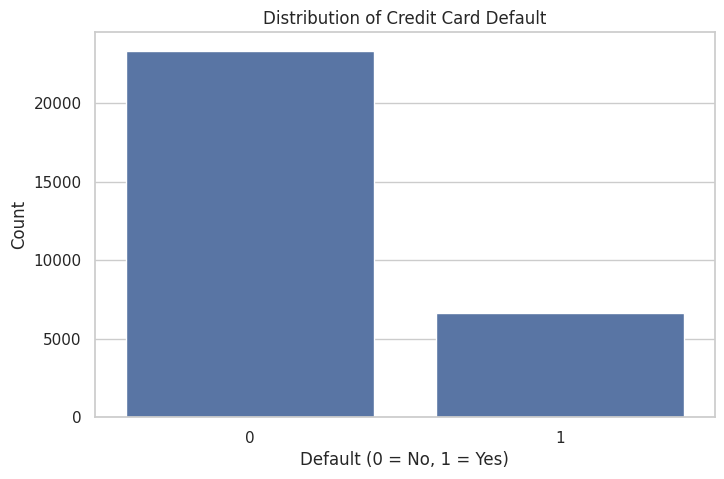

default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Distribution of target variable
plt.figure()
sns.countplot(x='default.payment.next.month', data=df)

plt.title("Distribution of Credit Card Default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

# Display percentage
default_percent = (
    df['default.payment.next.month']
    .value_counts(normalize=True) * 100
)

print(default_percent)

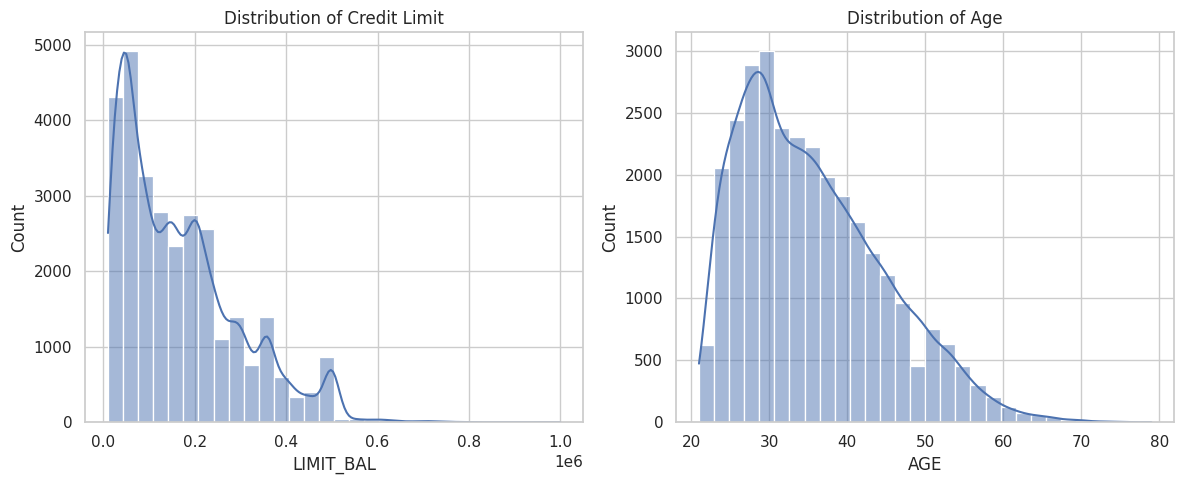

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
numerical_cols = ['LIMIT_BAL', 'AGE']

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['LIMIT_BAL'], bins=30, kde=True)
plt.title('Distribution of Credit Limit')

plt.subplot(1,2,2)
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title('Distribution of Age')

plt.tight_layout()
plt.show()

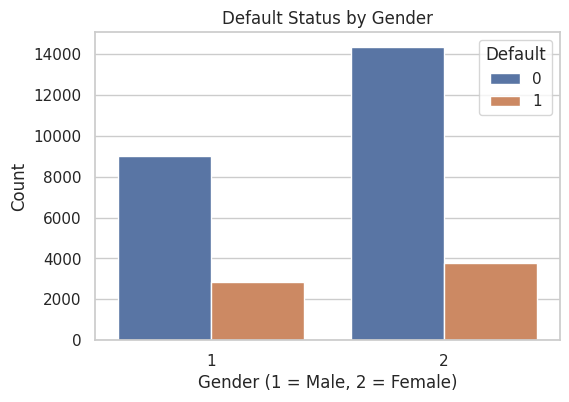

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='SEX', hue='default.payment.next.month', data=df)

plt.title('Default Status by Gender')
plt.xlabel('Gender (1 = Male, 2 = Female)')
plt.ylabel('Count')
plt.legend(title='Default')
plt.show()

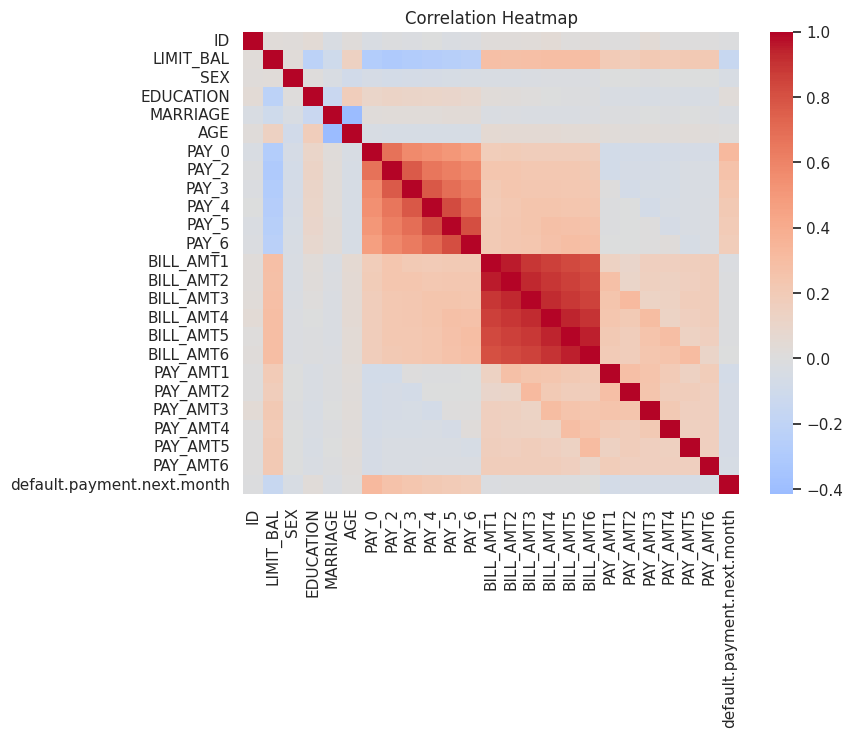

In [ ]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
plt.savefig(
    "/content/drive/MyDrive/Credit_Default_Research/Figures/Figure1_Target_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Credit_Default_Research/Figures/Figure1_Target_Distribution.png'

<Figure size 800x500 with 0 Axes>

In [ ]:
def save_figure(name):
    plt.savefig(
        os.path.join(FIGURE_PATH, f"{name}.png"),
        dpi=300,
        bbox_inches='tight'
    )
    print(f"✅ Figure saved: {name}.png")

In [ ]:
def save_table(table, name):
    table.to_csv(
        os.path.join(TABLE_PATH, f"{name}.csv"),
        index=True
    )
    print(f"✅ Table saved: {name}.csv")

In [ ]:
def save_dataset(dataframe, name):
    dataframe.to_csv(
        os.path.join(RESULT_PATH, f"{name}.csv"),
        index=False
    )
    print(f"✅ Dataset saved: {name}.csv")

In [ ]:
import joblib

def save_model(model, name):
    joblib.dump(
        model,
        os.path.join(MODEL_PATH, f"{name}.pkl")
    )
    print(f"✅ Model saved: {name}.pkl")

In [ ]:
def save_results(results_df, name):
    results_df.to_csv(
        os.path.join(RESULT_PATH, f"{name}.csv"),
        index=False
    )
    print(f"✅ Results saved: {name}.csv")

In [ ]:
from datetime import datetime

def log_step(step):

    with open(os.path.join(PROJECT_DIR, "Research_Log.txt"), "a") as f:
        f.write(f"{datetime.now()} --> {step}\n")

    print("✅ Research log updated.")

In [ ]:
def save_everything(dataframe, table, table_name, dataset_name):
    save_dataset(dataframe, dataset_name)
    save_table(table, table_name)
    log_step(f"Saved {dataset_name} and {table_name}")

In [ ]:
# Statistical Summary

summary_stats = df.describe().T

display(summary_stats)

# Save
save_table(summary_stats, "Table_1_Statistical_Summary")

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


NameError: name 'TABLE_PATH' is not defined

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Credit_Card_Default_Prediction"

DATASET_PATH = os.path.join(PROJECT_DIR, "Dataset")
FIGURE_PATH = os.path.join(PROJECT_DIR, "Figures")
TABLE_PATH = os.path.join(PROJECT_DIR, "Tables")
MODEL_PATH = os.path.join(PROJECT_DIR, "Models")
RESULT_PATH = os.path.join(PROJECT_DIR, "Results")
PAPER_PATH = os.path.join(PROJECT_DIR, "Paper")
REFERENCE_PATH = os.path.join(PROJECT_DIR, "References")

print(TABLE_PATH)

/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables


In [ ]:
def save_table(table, name):

    filepath = os.path.join(TABLE_PATH, f"{name}.csv")

    table.to_csv(filepath)

    print(f"✅ Saved at:\n{filepath}")

In [ ]:
summary_stats = df.describe().T

save_table(summary_stats, "Table_1_Statistical_Summary")

✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_1_Statistical_Summary.csv


In [ ]:
# ==========================================
# Unique Values in Categorical Features
# ==========================================

categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

for col in categorical_cols:
    print("="*50)
    print(f"{col}")
    print("="*50)
    print(df[col].value_counts().sort_index())
    print()

SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64



In [ ]:
cat_summary = pd.DataFrame()

for col in categorical_cols:
    temp = df[col].value_counts().sort_index()
    temp.name = col
    cat_summary = pd.concat([cat_summary, temp], axis=1)

save_table(cat_summary.fillna(0), "Table_3_Categorical_Value_Counts")

✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_3_Categorical_Value_Counts.csv


In [ ]:
# ==========================================
# Repayment Status Analysis
# ==========================================

pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

for col in pay_cols:
    print("="*50)
    print(col)
    print("="*50)
    print(df[col].value_counts().sort_index())
    print()

PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64

In [ ]:
pay_summary = pd.DataFrame()

for col in pay_cols:
    temp = df[col].value_counts().sort_index()
    temp.name = col
    pay_summary = pd.concat([pay_summary, temp], axis=1)

save_table(pay_summary.fillna(0), "Table_4_Repayment_Status")

✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_4_Repayment_Status.csv


In [ ]:
# ==========================================
# Outlier Percentage using IQR
# ==========================================

numerical_cols = [
    'LIMIT_BAL','AGE',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3',
    'PAY_AMT4','PAY_AMT5','PAY_AMT6'
]

outlier_summary = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "Feature": col,
        "Outliers": len(outliers),
        "Percentage": round(len(outliers)/len(df)*100,2)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

save_table(outlier_df, "Table_5_Outlier_Summary")

,Feature,Outliers,Percentage
0,LIMIT_BAL,167,0.56
1,AGE,272,0.91
2,BILL_AMT1,2400,8.00
3,BILL_AMT2,2395,7.98
4,BILL_AMT3,2469,8.23
5,BILL_AMT4,2622,8.74
6,BILL_AMT5,2725,9.08
7,BILL_AMT6,2693,8.98
8,PAY_AMT1,2745,9.15
9,PAY_AMT2,2714,9.05


✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_5_Outlier_Summary.csv


In [ ]:
class_dist = (
    df["default.payment.next.month"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

display(class_dist)

save_table(class_dist, "Table_6_Class_Distribution")

,Class,Count
0,0,23364
1,1,6636


✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_6_Class_Distribution.csv


In [ ]:
# ==========================================
# Feature Engineering
# ==========================================

# Average monthly bill
df["AVG_BILL_AMT"] = df[
    ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
     "BILL_AMT4","BILL_AMT5","BILL_AMT6"]
].mean(axis=1)

# Average monthly payment
df["AVG_PAY_AMT"] = df[
    ["PAY_AMT1","PAY_AMT2","PAY_AMT3",
     "PAY_AMT4","PAY_AMT5","PAY_AMT6"]
].mean(axis=1)

# Average repayment status
df["AVG_PAY_STATUS"] = df[
    ["PAY_0","PAY_2","PAY_3",
     "PAY_4","PAY_5","PAY_6"]
].mean(axis=1)

# Maximum repayment delay
df["MAX_PAY_STATUS"] = df[
    ["PAY_0","PAY_2","PAY_3",
     "PAY_4","PAY_5","PAY_6"]
].max(axis=1)

# Total bill amount
df["TOTAL_BILL"] = df[
    ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
     "BILL_AMT4","BILL_AMT5","BILL_AMT6"]
].sum(axis=1)

# Total payment amount
df["TOTAL_PAYMENT"] = df[
    ["PAY_AMT1","PAY_AMT2","PAY_AMT3",
     "PAY_AMT4","PAY_AMT5","PAY_AMT6"]
].sum(axis=1)

# Credit utilization ratio
df["CREDIT_UTILIZATION"] = (
    df["AVG_BILL_AMT"] / df["LIMIT_BAL"]
)

# Payment ratio
df["PAYMENT_RATIO"] = (
    df["TOTAL_PAYMENT"] /
    (df["TOTAL_BILL"].abs() + 1)
)

print("✅ Engineered features created successfully!")

✅ Engineered features created successfully!


In [ ]:
new_features = [
    "AVG_BILL_AMT",
    "AVG_PAY_AMT",
    "AVG_PAY_STATUS",
    "MAX_PAY_STATUS",
    "TOTAL_BILL",
    "TOTAL_PAYMENT",
    "CREDIT_UTILIZATION",
    "PAYMENT_RATIO"
]

display(df[new_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
AVG_BILL_AMT,30000.0,44976.945200,63260.721860,-56043.166667,4781.333333,21051.833333,57104.416667,8.773138e+05
AVG_PAY_AMT,30000.0,5275.232094,10137.946323,0.000000,1113.291667,2397.166667,5583.916667,6.273443e+05
AVG_PAY_STATUS,30000.0,-0.182439,0.982176,-2.000000,-0.833333,0.000000,0.000000,6.000000e+00
MAX_PAY_STATUS,30000.0,0.438733,1.345154,-2.000000,0.000000,0.000000,2.000000,8.000000e+00
TOTAL_BILL,30000.0,269861.671200,379564.331162,-336259.000000,28688.000000,126311.000000,342626.500000,5.263883e+06
TOTAL_PAYMENT,30000.0,31651.392567,60827.677939,0.000000,6679.750000,14383.000000,33503.500000,3.764066e+06
CREDIT_UTILIZATION,30000.0,0.373048,0.351890,-0.232590,0.029997,0.284834,0.687929,5.364308e+00
PAYMENT_RATIO,30000.0,21.216778,1255.766173,0.000000,0.041302,0.087865,0.608768,1.620000e+05


In [ ]:
engineered_summary = df[new_features].describe().T

save_table(
    engineered_summary,
    "Table_7_Engineered_Features"
)

✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_7_Engineered_Features.csv


In [ ]:
save_dataset(
    df,
    "Dataset_With_Engineered_Features"
)

✅ Dataset saved: Dataset_With_Engineered_Features.csv


In [ ]:
# ==========================================
# Remove ID Column
# ==========================================

df = df.drop(columns=["ID"])

print("Dataset Shape:", df.shape)

Dataset Shape: (30000, 32)


In [ ]:
# ==========================================
# Features and Target
# ==========================================

X = df.drop(columns=["default.payment.next.month"])
y = df["default.payment.next.month"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (30000, 31)
Target Shape   : (30000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (24000, 31)
Testing Set  : (6000, 31)


In [ ]:
train_df = X_train.copy()
train_df["default.payment.next.month"] = y_train.values

test_df = X_test.copy()
test_df["default.payment.next.month"] = y_test.values

save_dataset(train_df, "Training_Dataset")
save_dataset(test_df, "Testing_Dataset")

✅ Dataset saved: Training_Dataset.csv
✅ Dataset saved: Testing_Dataset.csv


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [ ]:
save_model(scaler, "StandardScaler")

✅ Model saved: StandardScaler.pkl


In [ ]:
print("Training Target Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True))

Training Target Distribution
default.payment.next.month
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Testing Target Distribution
default.payment.next.month
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [ ]:
log_step("Completed data preprocessing and train-test split.")

✅ Research log updated.


In [ ]:
# ==========================================
# Machine Learning Models
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd

In [ ]:
# ==========================================
# Model Evaluation Function
# ==========================================

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1]

    results = {

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1 Score": f1_score(y_test, predictions),

        "ROC AUC": roc_auc_score(y_test, probabilities)

    }

    print(classification_report(y_test, predictions))

    return results, predictions

In [ ]:
# ==========================================
# Logistic Regression
# ==========================================

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_results, lr_predictions = evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

print(lr_results)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.35      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

{'Accuracy': 0.8078333333333333, 'Precision': 0.6924778761061947, 'Recall': 0.23587038432554636, 'F1 Score': 0.3518830803822372, 'ROC AUC': np.float64(0.7241534567173961)}


In [ ]:
# ==========================================
# Decision Tree
# ==========================================

dt = DecisionTreeClassifier(
    random_state=42
)

dt_results, dt_predictions = evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)

print(dt_results)

              precision    recall  f1-score   support

           0       0.83      0.82      0.83      4673
           1       0.40      0.42      0.41      1327

    accuracy                           0.73      6000
   macro avg       0.62      0.62      0.62      6000
weighted avg       0.74      0.73      0.73      6000

{'Accuracy': 0.7311666666666666, 'Precision': 0.39829302987197723, 'Recall': 0.42200452147701584, 'F1 Score': 0.40980607391145263, 'ROC AUC': np.float64(0.6216547109362237)}


In [ ]:
# ==========================================
# Random Forest
# ==========================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_results, rf_predictions = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

print(rf_results)

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

{'Accuracy': 0.8118333333333333, 'Precision': 0.6295811518324608, 'Recall': 0.3624717407686511, 'F1 Score': 0.4600669536107126, 'ROC AUC': np.float64(0.7572852334701538)}


In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_results["Accuracy"],
        dt_results["Accuracy"],
        rf_results["Accuracy"]
    ],

    "Precision":[
        lr_results["Precision"],
        dt_results["Precision"],
        rf_results["Precision"]
    ],

    "Recall":[
        lr_results["Recall"],
        dt_results["Recall"],
        rf_results["Recall"]
    ],

    "F1 Score":[
        lr_results["F1 Score"],
        dt_results["F1 Score"],
        rf_results["F1 Score"]
    ],

    "ROC AUC":[
        lr_results["ROC AUC"],
        dt_results["ROC AUC"],
        rf_results["ROC AUC"]
    ]

})

display(comparison)

save_table(comparison, "Table_8_Baseline_Model_Comparison")

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.807833,0.692478,0.235870,0.351883,0.724153
1,Decision Tree,0.731167,0.398293,0.422005,0.409806,0.621655
2,Random Forest,0.811833,0.629581,0.362472,0.460067,0.757285


✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_8_Baseline_Model_Comparison.csv


In [ ]:
save_model(lr, "LogisticRegression")
save_model(dt, "DecisionTree")
save_model(rf, "RandomForest")

✅ Model saved: LogisticRegression.pkl
✅ Model saved: DecisionTree.pkl
✅ Model saved: RandomForest.pkl


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

In [ ]:
def evaluate_model(
    model,
    model_name,
    X_train,
    X_test,
    y_train,
    y_test,
    scaled=False
):

    start_train = time.time()

    model.fit(X_train, y_train)

    end_train = time.time()

    start_pred = time.time()

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    end_pred = time.time()

    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc = roc_auc_score(y_test,y_prob)

    print("="*60)
    print(model_name)
    print("="*60)

    print(classification_report(y_test,y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5,5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )

    plt.title(f"{model_name} Confusion Matrix")

    save_figure(f"{model_name}_Confusion_Matrix")

    plt.show()

    # ROC Curve
    RocCurveDisplay.from_predictions(
        y_test,
        y_prob
    )

    plt.title(f"{model_name} ROC Curve")

    save_figure(f"{model_name}_ROC")

    plt.show()

    return {

        "Model":model_name,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1 Score":f1,

        "ROC AUC":roc,

        "Training Time":end_train-start_train,

        "Prediction Time":end_pred-start_pred

    }

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

✅ Figure saved: Random Forest_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

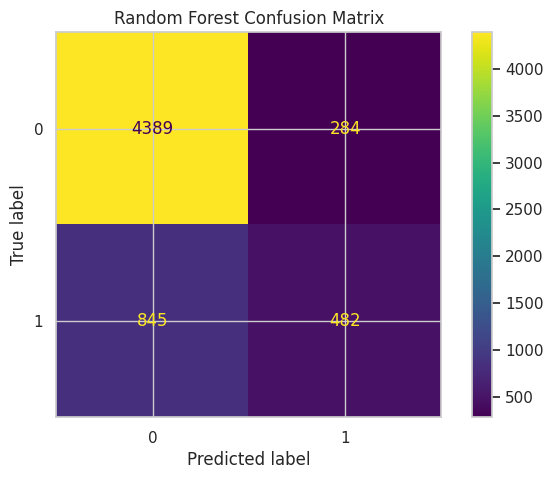

✅ Figure saved: Random Forest_ROC.png


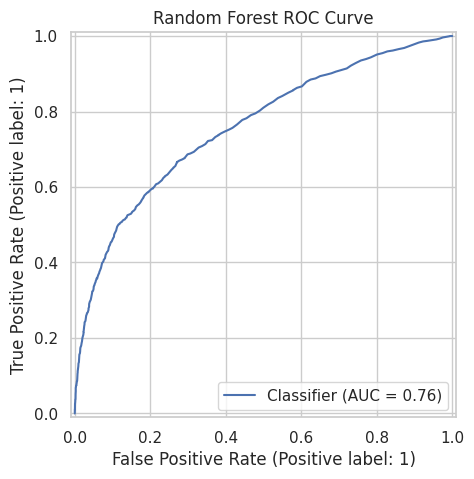

✅ Model saved: RandomForest300.pkl


In [ ]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1

)

rf_result = evaluate_model(

    rf,

    "Random Forest",

    X_train,

    X_test,

    y_train,

    y_test

)

save_model(rf,"RandomForest300")

In [ ]:
results = pd.DataFrame([

    lr_results,

    dt_results,

    rf_result

])

display(results)

save_table(

    results,

    "Table_9_Baseline_Results"

)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Model,Training Time,Prediction Time
0,0.807833,0.692478,0.235870,0.351883,0.724153,NaN,NaN,NaN
1,0.731167,0.398293,0.422005,0.409806,0.621655,NaN,NaN,NaN
2,0.811833,0.629243,0.363225,0.460583,0.759108,Random Forest,38.697782,1.002693


✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_9_Baseline_Results.csv


In [ ]:
!pip install xgboost lightgbm catboost -q

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

XGBoost
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: XGBoost_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

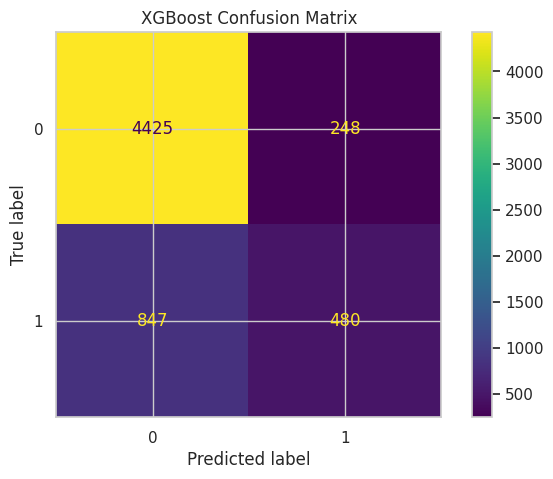

✅ Figure saved: XGBoost_ROC.png


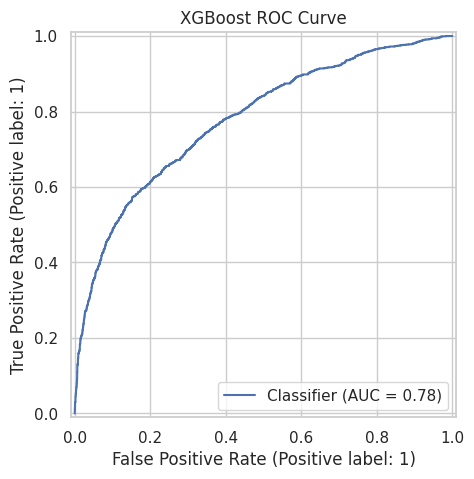

✅ Model saved: XGBoost.pkl


In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_result = evaluate_model(
    xgb,
    "XGBoost",
    X_train,
    X_test,
    y_train,
    y_test
)

save_model(xgb, "XGBoost")

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4847
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
LightGBM
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: LightGBM_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

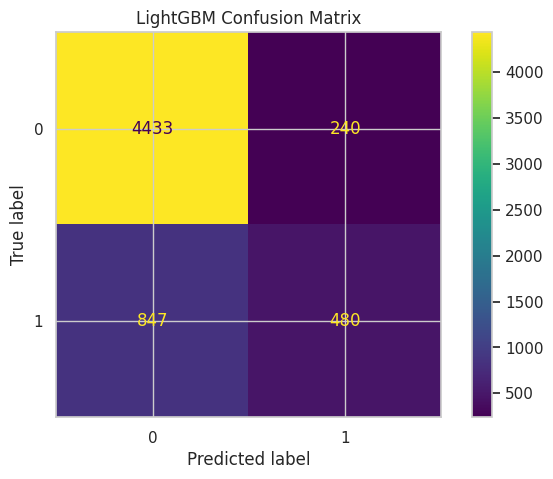

✅ Figure saved: LightGBM_ROC.png


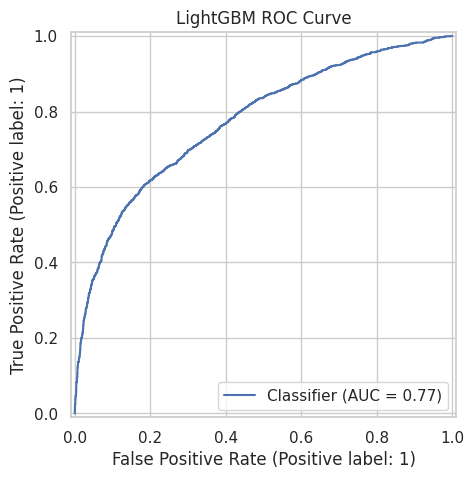

✅ Model saved: LightGBM.pkl


In [ ]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm_result = evaluate_model(
    lgbm,
    "LightGBM",
    X_train,
    X_test,
    y_train,
    y_test
)

save_model(lgbm, "LightGBM")

CatBoost
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: CatBoost_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

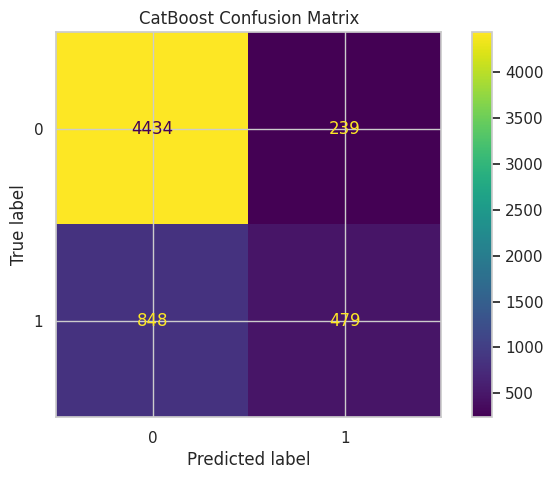

✅ Figure saved: CatBoost_ROC.png


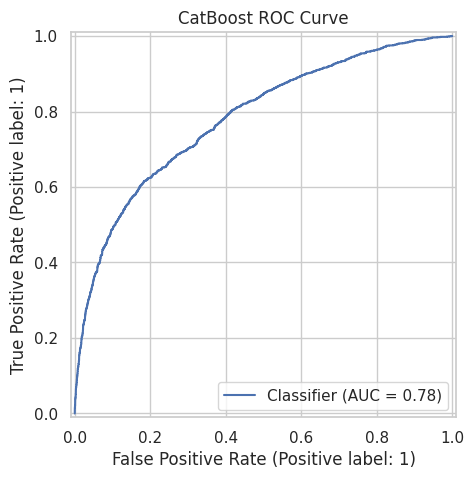

✅ Model saved: CatBoost.pkl


In [ ]:
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

cat_result = evaluate_model(
    cat,
    "CatBoost",
    X_train,
    X_test,
    y_train,
    y_test
)

save_model(cat, "CatBoost")

In [ ]:
def save_results(df, filename):
    filepath = os.path.join(RESULT_PATH, f"{filename}.csv")
    df.to_csv(filepath, index=False)
    print(f"✅ Results saved at:\n{filepath}")

In [ ]:
save_model(xgb, "XGBoost")

✅ Model saved: XGBoost.pkl


In [ ]:
import joblib
import os

In [ ]:
save_model(lr, "Logistic_Regression")

✅ Model saved: Logistic_Regression.pkl


In [ ]:
save_model(dt, "Decision_Tree")

✅ Model saved: Decision_Tree.pkl


In [ ]:
save_model(rf, "Random_Forest")

✅ Model saved: Random_Forest.pkl


In [ ]:
save_model(xgb, "XGBoost")

✅ Model saved: XGBoost.pkl


In [ ]:
save_model(lgbm, "LightGBM")

✅ Model saved: LightGBM.pkl


In [ ]:
save_model(cat, "CatBoost")

✅ Model saved: CatBoost.pkl


In [ ]:
save_model(scaler, "StandardScaler")

✅ Model saved: StandardScaler.pkl


In [ ]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
CatBoostClassifier       type                      <class 'catboost.core.CatBoostClassifier'>
ConfusionMatrixDisplay   type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DATASET_PATH             str                       /content/drive/MyDrive/Cr<...>efault_Prediction/Dataset
DecisionTreeClassifier   ABCMeta                   <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
FIGURE_PATH              str                       /content/drive/MyDrive/Cr<...>efault_Prediction/Figures
GridSearchCV             ABCMeta                   <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
IQR                      float64                   3882.25
LGBMClassifier           type                      <class 'lightgbm.sklearn.LGBMClassifier'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticReg

XGBoost
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: XGBoost_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

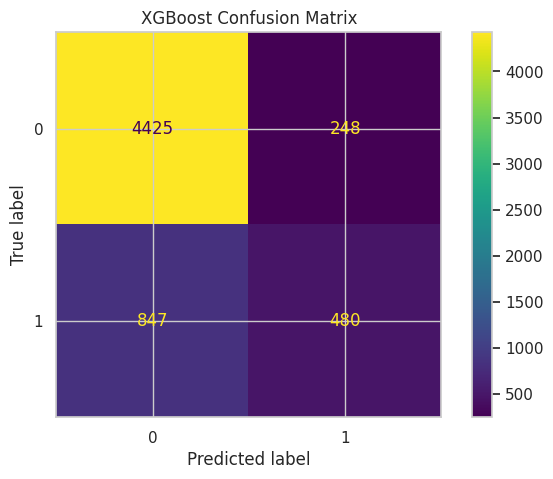

✅ Figure saved: XGBoost_ROC.png


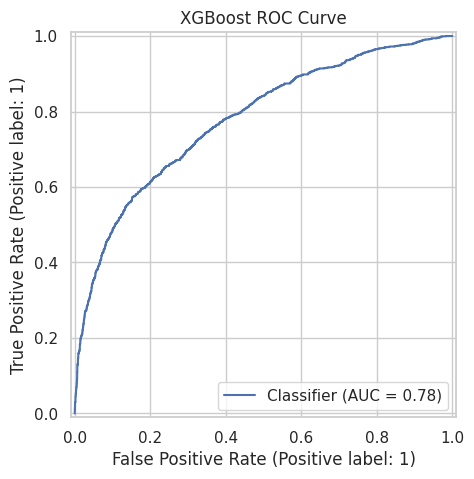

✅ Model saved: XGBoost.pkl
✅ Results saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Results/XGBoost_Results.csv


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_result = evaluate_model(
    xgb,
    "XGBoost",
    X_train,
    X_test,
    y_train,
    y_test
)

save_model(xgb, "XGBoost")

xgb_df = pd.DataFrame([xgb_result])
save_results(xgb_df, "XGBoost_Results")

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004355 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4847
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
LightGBM
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: LightGBM_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

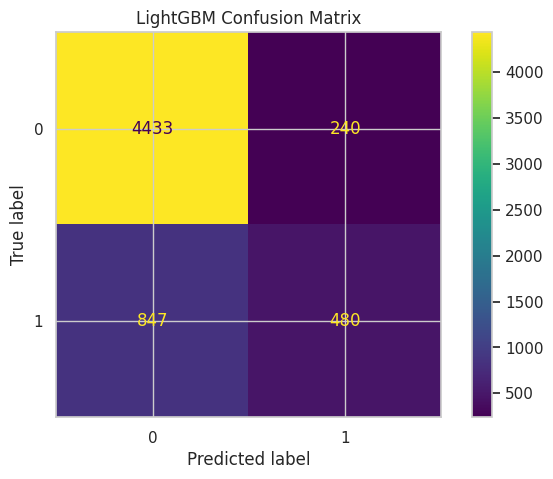

✅ Figure saved: LightGBM_ROC.png


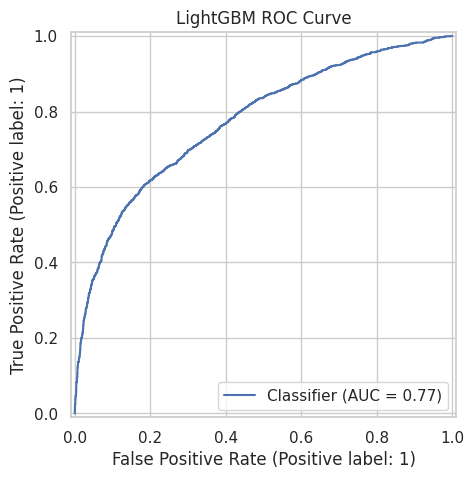

In [ ]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgbm_result = evaluate_model(
    lgbm,
    "LightGBM",
    X_train,
    X_test,
    y_train,
    y_test
)

In [ ]:
save_model(lgbm, "LightGBM")

lgbm_df = pd.DataFrame([lgbm_result])

save_results(
    lgbm_df,
    "LightGBM_Results"
)

✅ Model saved: LightGBM.pkl
✅ Results saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Results/LightGBM_Results.csv


CatBoost
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: CatBoost_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

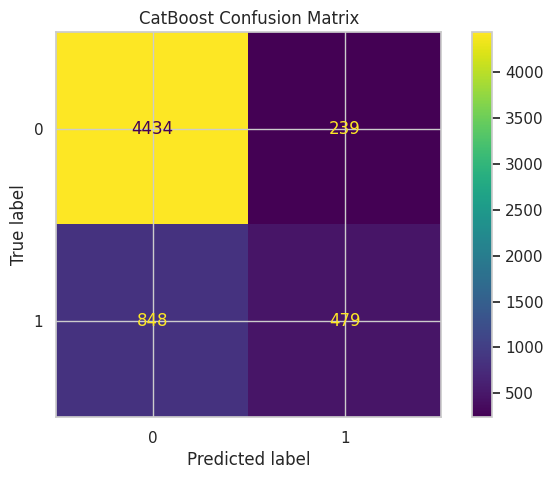

✅ Figure saved: CatBoost_ROC.png


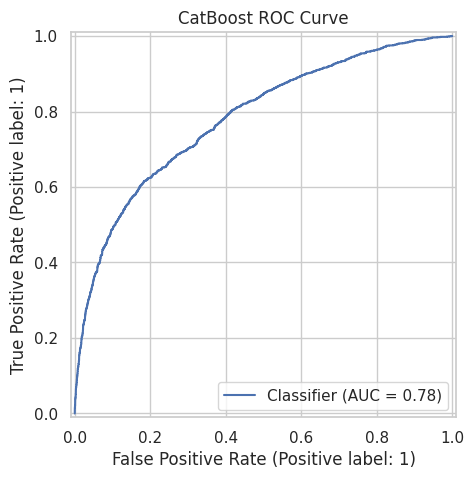

In [ ]:
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    random_state=42,
    verbose=0
)

cat_result = evaluate_model(
    cat,
    "CatBoost",
    X_train,
    X_test,
    y_train,
    y_test
)

In [ ]:
save_model(cat, "CatBoost")

cat_df = pd.DataFrame([cat_result])

save_results(
    cat_df,
    "CatBoost_Results"
)

✅ Model saved: CatBoost.pkl
✅ Results saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Results/CatBoost_Results.csv


In [ ]:
comparison_table = pd.DataFrame([

    lr_results,
    dt_results,
    rf_result,
    xgb_result,
    lgbm_result,
    cat_result

])

comparison_table = comparison_table.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

display(comparison_table)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Model,Training Time,Prediction Time
0,0.818833,0.667131,0.360965,0.468460,0.782091,CatBoost,6.384476,0.028972
1,0.817500,0.659341,0.361718,0.467153,0.778592,XGBoost,9.018888,0.196292
2,0.818833,0.666667,0.361718,0.468979,0.774550,LightGBM,3.376552,0.447248
3,0.811833,0.629243,0.363225,0.460583,0.759108,Random Forest,38.697782,1.002693
4,0.807833,0.692478,0.235870,0.351883,0.724153,NaN,NaN,NaN
5,0.731167,0.398293,0.422005,0.409806,0.621655,NaN,NaN,NaN


In [ ]:
save_table(
    comparison_table,
    "Table_10_Final_Model_Comparison"
)

save_results(
    comparison_table,
    "Final_Model_Comparison"
)

✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_10_Final_Model_Comparison.csv
✅ Results saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Results/Final_Model_Comparison.csv


In [ ]:
# =====================================
# Feature Engineering
# =====================================

# Average bill amount
df["AVG_BILL"] = df[
    ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
     "BILL_AMT4","BILL_AMT5","BILL_AMT6"]
].mean(axis=1)

# Average payment amount
df["AVG_PAYMENT"] = df[
    ["PAY_AMT1","PAY_AMT2","PAY_AMT3",
     "PAY_AMT4","PAY_AMT5","PAY_AMT6"]
].mean(axis=1)

# Total bill
df["TOTAL_BILL"] = df[
    ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
     "BILL_AMT4","BILL_AMT5","BILL_AMT6"]
].sum(axis=1)

# Total payment
df["TOTAL_PAYMENT"] = df[
    ["PAY_AMT1","PAY_AMT2","PAY_AMT3",
     "PAY_AMT4","PAY_AMT5","PAY_AMT6"]
].sum(axis=1)

# Credit utilization
df["CREDIT_UTILIZATION"] = (
    df["TOTAL_BILL"] /
    (df["LIMIT_BAL"] * 6)
)

# Maximum payment delay
df["MAX_DELAY"] = df[
    ["PAY_0","PAY_2","PAY_3",
     "PAY_4","PAY_5","PAY_6"]
].max(axis=1)

# Average payment delay
df["AVG_DELAY"] = df[
    ["PAY_0","PAY_2","PAY_3",
     "PAY_4","PAY_5","PAY_6"]
].mean(axis=1)

print("New Dataset Shape:", df.shape)

display(df.head())

New Dataset Shape: (30000, 36)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,AVG_PAY_STATUS,MAX_PAY_STATUS,TOTAL_BILL,TOTAL_PAYMENT,CREDIT_UTILIZATION,PAYMENT_RATIO,AVG_BILL,AVG_PAYMENT,MAX_DELAY,AVG_DELAY
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,-0.333333,2,7704.0,689.0,0.064200,0.089422,1284.000000,114.833333,2,-0.333333
1,120000.0,2,2,2,26,-1,2,0,0,0,...,0.500000,2,17077.0,5000.0,0.023718,0.292774,2846.166667,833.333333,2,0.500000
2,90000.0,2,2,2,34,0,0,0,0,0,...,0.000000,0,101653.0,11018.0,0.188246,0.108387,16942.166667,1836.333333,0,0.000000
3,50000.0,2,2,1,37,0,0,0,0,0,...,0.000000,0,231334.0,8388.0,0.771113,0.036259,38555.666667,1398.000000,0,0.000000
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,-0.333333,0,109339.0,59049.0,0.364463,0.540049,18223.166667,9841.500000,0,-0.333333


In [ ]:
# Save engineered dataset
engineered_path = os.path.join(
    DATASET_PATH,
    "Credit_Card_Default_Engineered.csv"
)

df.to_csv(engineered_path, index=False)

print("✅ Engineered dataset saved:")
print(engineered_path)

✅ Engineered dataset saved:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Dataset/Credit_Card_Default_Engineered.csv


In [ ]:
# Save engineered dataset
engineered_path = os.path.join(
    DATASET_PATH,
    "Credit_Card_Default_Engineered.csv"
)

df.to_csv(engineered_path, index=False)

print("✅ Engineered dataset saved:")
print(engineered_path)

✅ Engineered dataset saved:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Dataset/Credit_Card_Default_Engineered.csv


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_columns = X_train.select_dtypes(include=['int64','float64']).columns

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

In [ ]:
save_model(scaler, "StandardScaler_Engineered")

✅ Model saved: StandardScaler_Engineered.pkl


Logistic Regression (Engineered)
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.35      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

✅ Figure saved: Logistic Regression (Engineered)_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

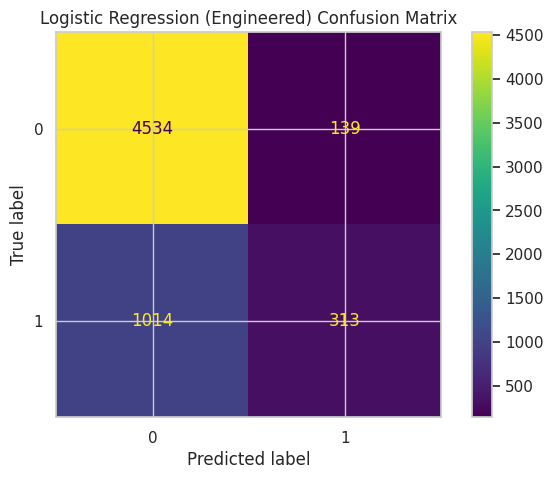

✅ Figure saved: Logistic Regression (Engineered)_ROC.png


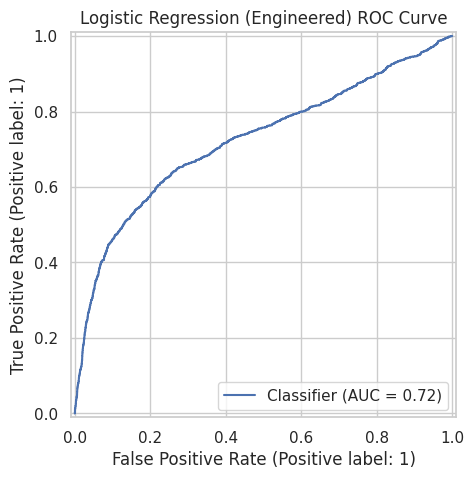

✅ Model saved: LR_Engineered.pkl


In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_engineered_result = evaluate_model(
    lr,
    "Logistic Regression (Engineered)",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

save_model(lr, "LR_Engineered")

CatBoost (Engineered)
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: CatBoost (Engineered)_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

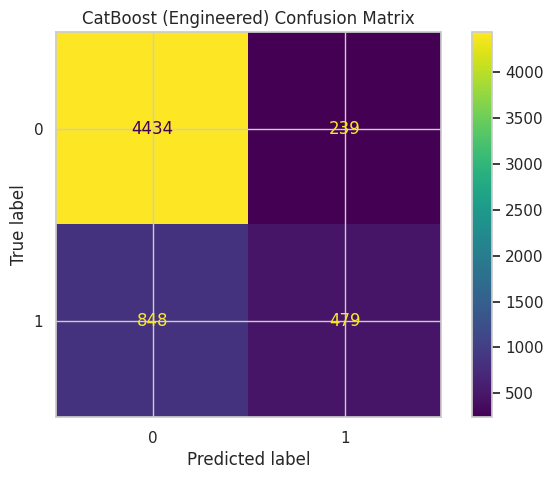

✅ Figure saved: CatBoost (Engineered)_ROC.png


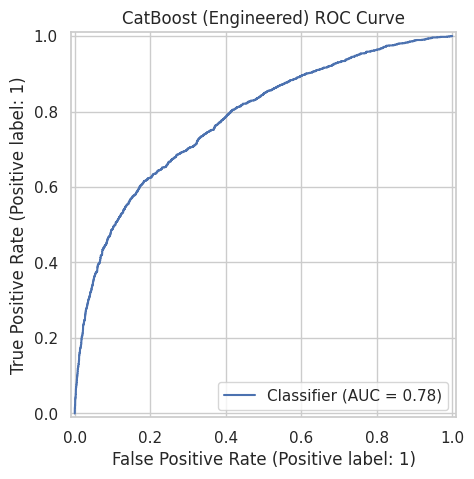

✅ Model saved: CatBoost_Engineered.pkl


In [ ]:
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

cat_engineered_result = evaluate_model(
    cat,
    "CatBoost (Engineered)",
    X_train,
    X_test,
    y_train,
    y_test
)

save_model(cat, "CatBoost_Engineered")

In [ ]:
ablation_table = pd.DataFrame([
    {
        "Model": "CatBoost",
        "Original ROC-AUC": cat_result["ROC AUC"],
        "Engineered ROC-AUC": cat_engineered_result["ROC AUC"],
        "Improvement": cat_engineered_result["ROC AUC"] - cat_result["ROC AUC"]
    },
    {
        "Model": "Logistic Regression",
        "Original ROC-AUC": lr_results["ROC AUC"],
        "Engineered ROC-AUC": lr_engineered_result["ROC AUC"],
        "Improvement": lr_engineered_result["ROC AUC"] - lr_results["ROC AUC"]
    }
])

display(ablation_table)

save_table(ablation_table, "Table_12_Ablation_Study")

,Model,Original ROC-AUC,Engineered ROC-AUC,Improvement
0,CatBoost,0.782091,0.782091,0.0
1,Logistic Regression,0.724153,0.724153,0.0


✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_12_Ablation_Study.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
importance = cat.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
5,PAY_0,11.992453
29,CREDIT_UTILIZATION,7.091232
26,MAX_PAY_STATUS,6.847433
0,LIMIT_BAL,5.938226
11,BILL_AMT1,5.480696
25,AVG_PAY_STATUS,5.093723
30,PAYMENT_RATIO,4.021543
4,AGE,3.838512
20,PAY_AMT4,3.420139
19,PAY_AMT3,3.413184


In [ ]:
save_table(
    feature_importance,
    "Table_13_CatBoost_Feature_Importance"
)

✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_13_CatBoost_Feature_Importance.csv


✅ Figure saved: Figure_12_CatBoost_Feature_Importance.png


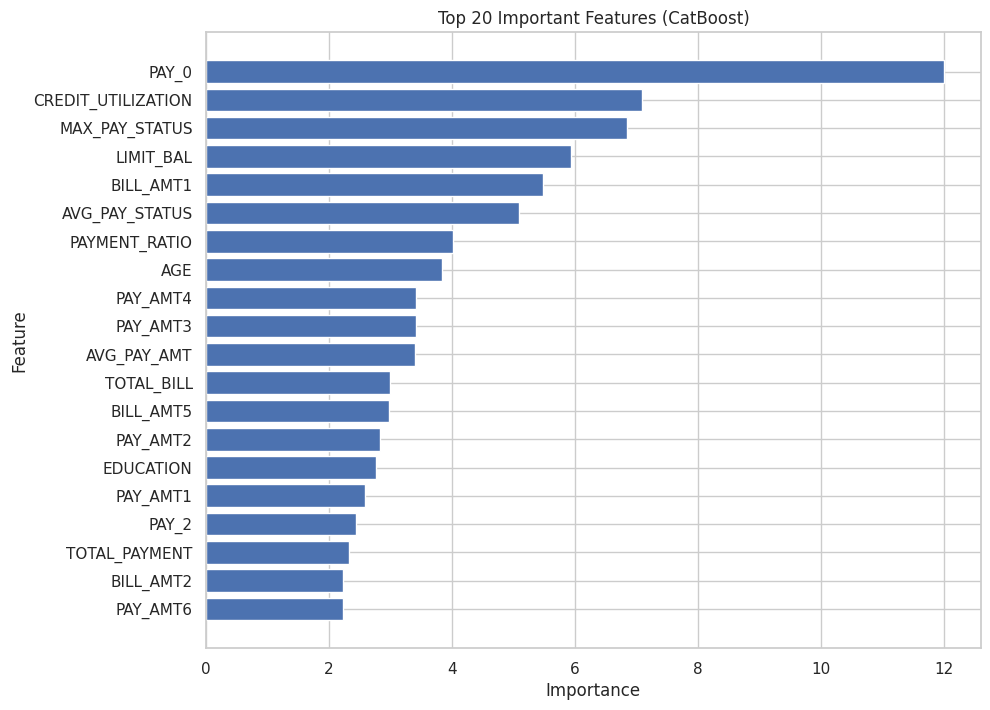

In [ ]:
plt.figure(figsize=(10,8))

top20 = feature_importance.head(20)

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features (CatBoost)")

plt.gca().invert_yaxis()

save_figure("Figure_12_CatBoost_Feature_Importance")

plt.show()

In [ ]:
!pip install shap -q

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(cat)

shap_values = explainer.shap_values(X_test)

✅ Figure saved: Figure_13_SHAP_Summary.png


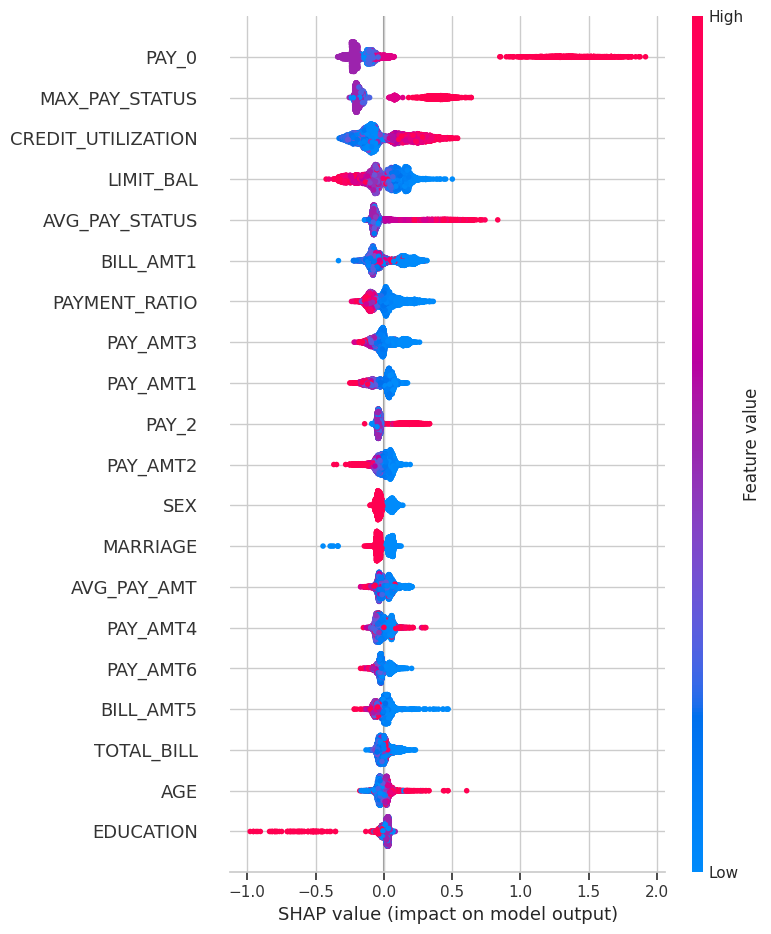

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

save_figure("Figure_13_SHAP_Summary")

plt.show()

✅ Figure saved: Figure_14_SHAP_Bar.png


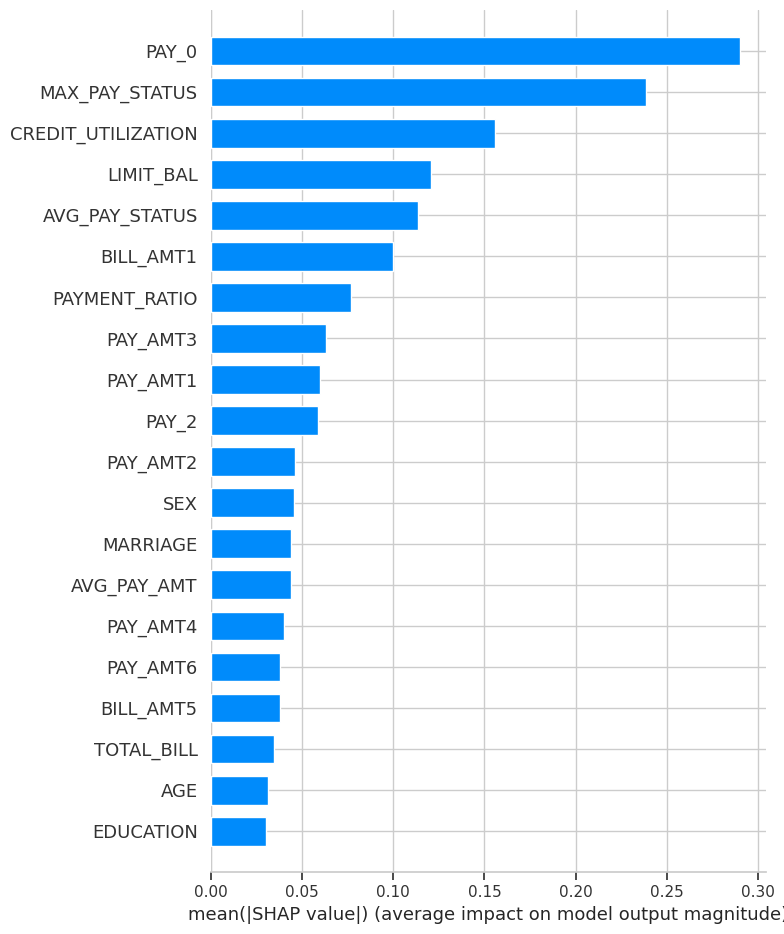

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

save_figure("Figure_14_SHAP_Bar")

plt.show()

In [ ]:
import joblib

joblib.dump(
    shap_values,
    os.path.join(
        RESULT_PATH,
        "SHAP_Values.pkl"
    )
)

print("✅ SHAP values saved")

✅ SHAP values saved


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat
}

cv_results = []

for name, model in models.items():

    # Logistic Regression requires scaled features
    if name == "Logistic Regression":
        scores = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        )
    else:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        )

    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

cv_results = pd.DataFrame(cv_results)

display(cv_results)

,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.742160,0.010492
1,Decision Tree,0.614792,0.003386
2,Random Forest,0.767983,0.002750
3,XGBoost,0.781160,0.005845
4,LightGBM,0.779177,0.005470
5,CatBoost,0.786895,0.005238


In [ ]:
save_table(
    cv_results,
    "Table_14_CrossValidation_Results"
)

save_results(
    cv_results,
    "CrossValidation_Results"
)

✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_14_CrossValidation_Results.csv
✅ Results saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Results/CrossValidation_Results.csv


✅ Figure saved: Figure_15_CrossValidation.png


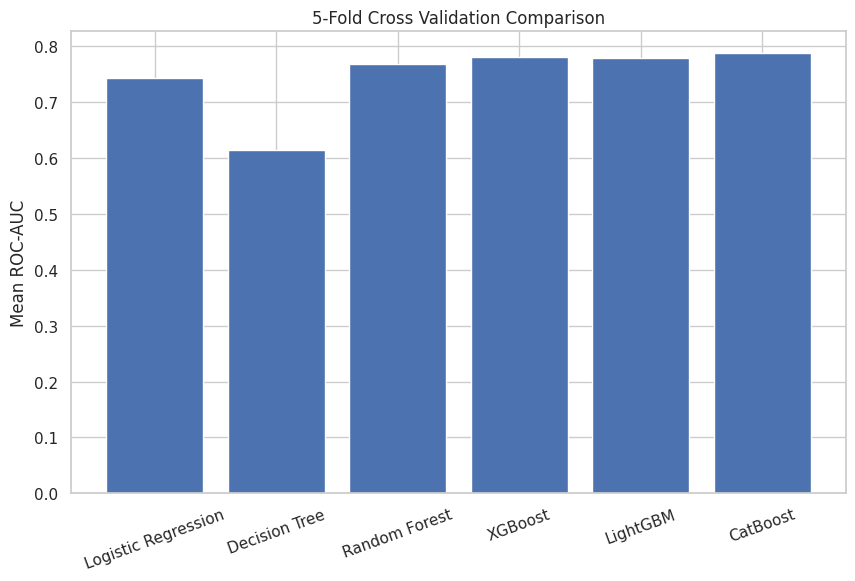

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(
    cv_results["Model"],
    cv_results["Mean ROC-AUC"]
)

plt.xticks(rotation=20)

plt.ylabel("Mean ROC-AUC")

plt.title("5-Fold Cross Validation Comparison")

save_figure("Figure_15_CrossValidation")

plt.show()

In [ ]:
engineered_features = [
    "AVG_BILL",
    "AVG_PAYMENT",
    "TOTAL_BILL",
    "TOTAL_PAYMENT",
    "CREDIT_UTILIZATION",
    "MAX_DELAY",
    "AVG_DELAY"
]

print(df[engineered_features].head())

print("\nTotal Features:", len(df.columns))

       AVG_BILL  AVG_PAYMENT  TOTAL_BILL  TOTAL_PAYMENT  CREDIT_UTILIZATION  \
0   1284.000000   114.833333      7704.0          689.0            0.064200   
1   2846.166667   833.333333     17077.0         5000.0            0.023718   
2  16942.166667  1836.333333    101653.0        11018.0            0.188246   
3  38555.666667  1398.000000    231334.0         8388.0            0.771113   
4  18223.166667  9841.500000    109339.0        59049.0            0.364463   

   MAX_DELAY  AVG_DELAY  
0          2  -0.333333  
1          2   0.500000  
2          0   0.000000  
3          0   0.000000  
4          0  -0.333333  

Total Features: 36


In [ ]:
feature_table = pd.DataFrame({
    "Feature Name": df.columns
})

display(feature_table)

save_table(
    feature_table,
    "Table_15_All_Features"
)

,Feature Name
0,LIMIT_BAL
1,SEX
2,EDUCATION
3,MARRIAGE
4,AGE
5,PAY_0
6,PAY_2
7,PAY_3
8,PAY_4
9,PAY_5


✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_15_All_Features.csv


✅ Figure saved: Figure_16_Engineered_Feature_Correlation.png


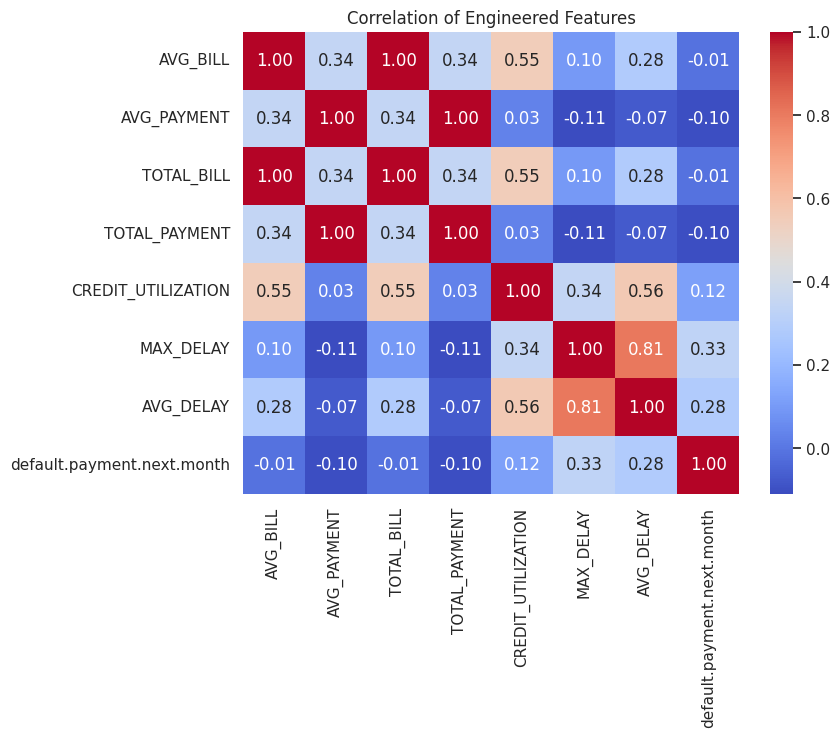

In [ ]:
plt.figure(figsize=(8,6))

corr = df[engineered_features + ["default.payment.next.month"]].corr()

import seaborn as sns

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Engineered Features")

save_figure("Figure_16_Engineered_Feature_Correlation")

plt.show()

In [ ]:
engineered_dataset_path = os.path.join(
    DATASET_PATH,
    "Credit_Card_Default_Engineered.csv"
)

df.to_csv(
    engineered_dataset_path,
    index=False
)

print("✅ Engineered dataset saved!")
print(engineered_dataset_path)

✅ Engineered dataset saved!
/content/drive/MyDrive/Credit_Card_Default_Prediction/Dataset/Credit_Card_Default_Engineered.csv


In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(20))

,Feature,Importance
5,PAY_0,11.992453
29,CREDIT_UTILIZATION,7.091232
26,MAX_PAY_STATUS,6.847433
0,LIMIT_BAL,5.938226
11,BILL_AMT1,5.480696
25,AVG_PAY_STATUS,5.093723
30,PAYMENT_RATIO,4.021543
4,AGE,3.838512
20,PAY_AMT4,3.420139
19,PAY_AMT3,3.413184


In [ ]:
save_table(
    importance,
    "Table_16_CatBoost_FeatureImportance"
)

✅ Saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Tables/Table_16_CatBoost_FeatureImportance.csv


✅ Figure saved: Figure_17_CatBoost_FeatureImportance.png


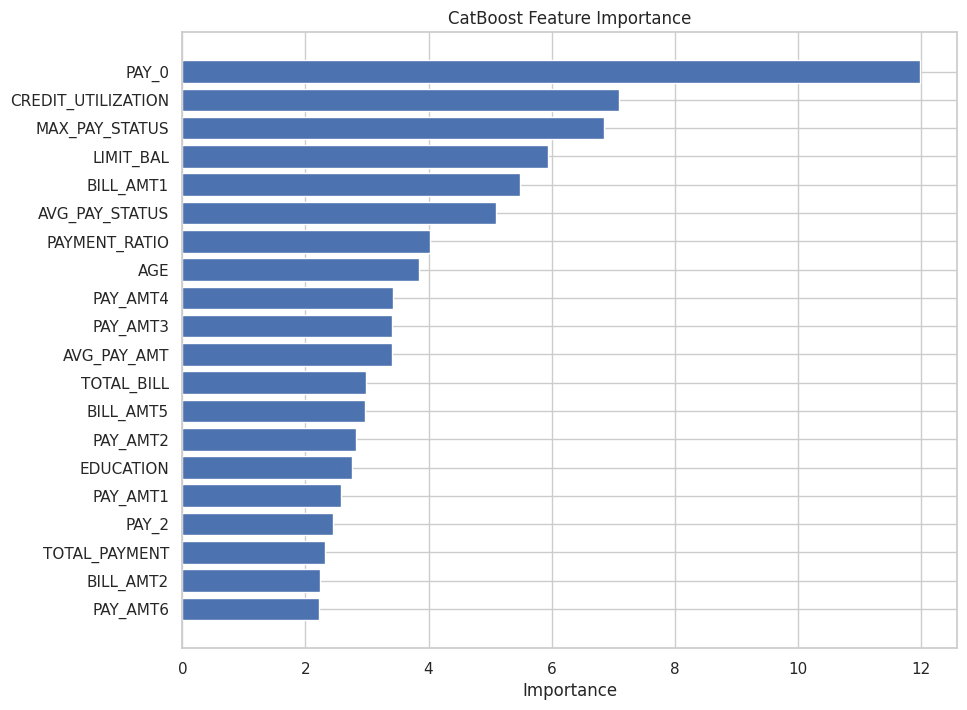

In [ ]:
plt.figure(figsize=(10,8))

top20 = importance.head(20)

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("CatBoost Feature Importance")

save_figure("Figure_17_CatBoost_FeatureImportance")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

cat_params = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [200, 300, 500]
}

cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

grid_cat = GridSearchCV(
    estimator=cat_model,
    param_grid=cat_params,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_cat.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5, estimator=CatBoostClassifier(random_state=42, verbose=0),
             n_jobs=-1,
             param_grid={'depth': [4, 6, 8], 'iterations': [200, 300, 500],
                         'learning_rate': [0.01, 0.05, 0.1]},
             scoring='roc_auc', verbose=2)

In [ ]:
print("Best Parameters:")
print(grid_cat.best_params_)

print("\nBest ROC-AUC:")
print(grid_cat.best_score_)

Best Parameters:
{'depth': 6, 'iterations': 200, 'learning_rate': 0.05}

Best ROC-AUC:
0.7872899116454457


In [ ]:
best_cat = grid_cat.best_estimator_

save_model(best_cat, "Best_CatBoost")

✅ Model saved: Best_CatBoost.pkl


Tuned CatBoost
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: Tuned CatBoost_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

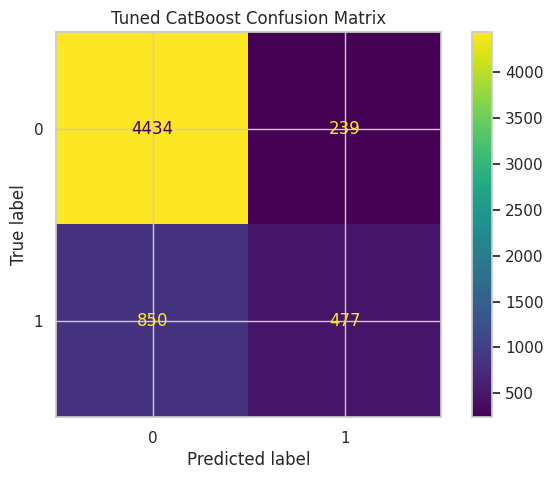

✅ Figure saved: Tuned CatBoost_ROC.png


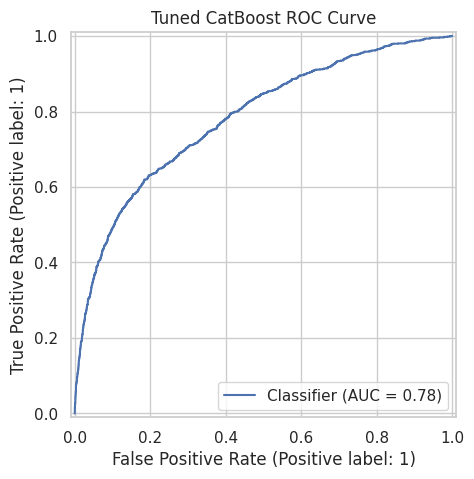

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,Tuned CatBoost,0.8185,0.666201,0.359457,0.46696,0.78232,4.574557,0.013066


In [ ]:
best_cat_result = evaluate_model(
    best_cat,
    "Tuned CatBoost",
    X_train,
    X_test,
    y_train,
    y_test
)

display(pd.DataFrame([best_cat_result]))

In [ ]:
save_results(
    pd.DataFrame([best_cat_result]),
    "Tuned_CatBoost_Results"
)

✅ Results saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Results/Tuned_CatBoost_Results.csv


In [ ]:
!pip install shap -q

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(cat)

In [ ]:
shap_values = explainer.shap_values(X_test)

✅ Figure saved: Figure_18_SHAP_Summary.png


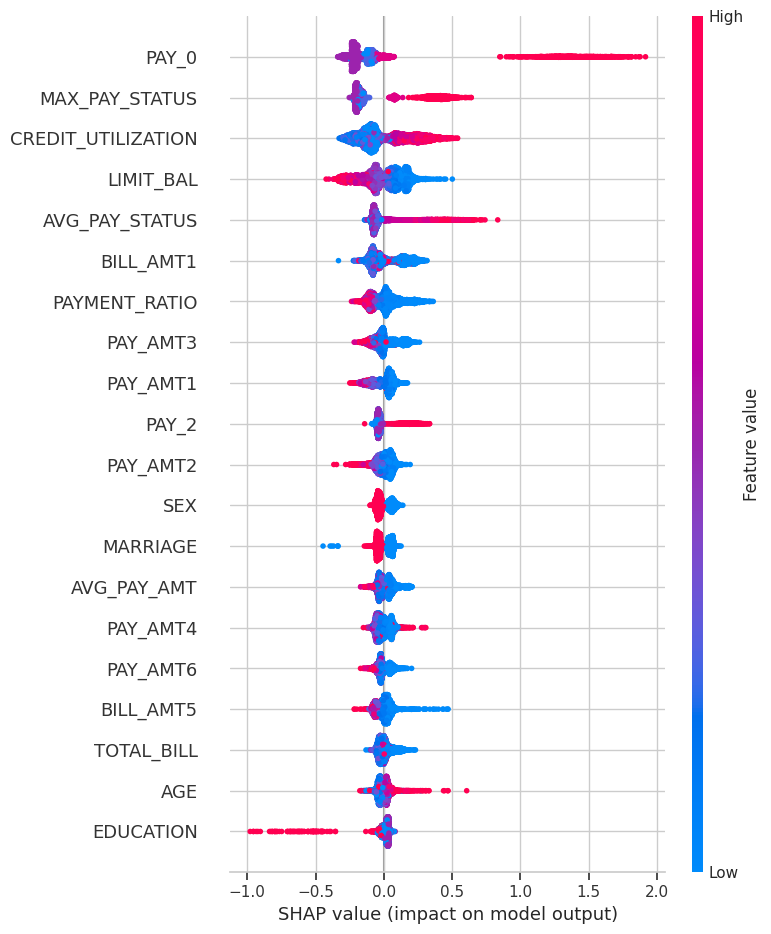

In [ ]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

save_figure("Figure_18_SHAP_Summary")

plt.show()

✅ Figure saved: Figure_19_SHAP_Bar.png


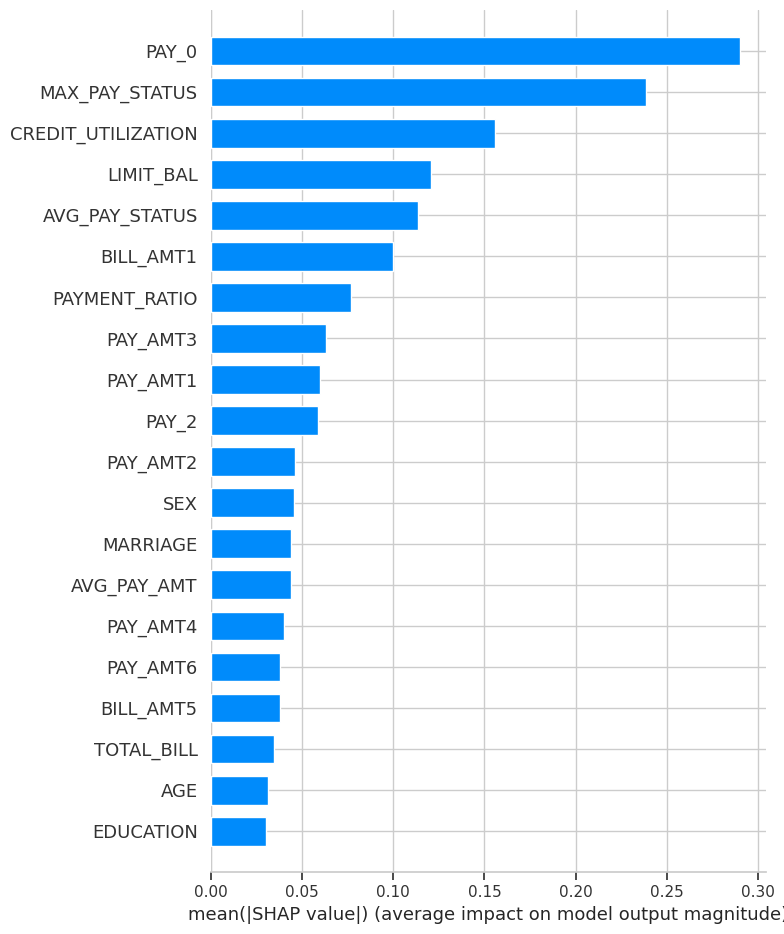

In [ ]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

save_figure("Figure_19_SHAP_Bar")

plt.show()

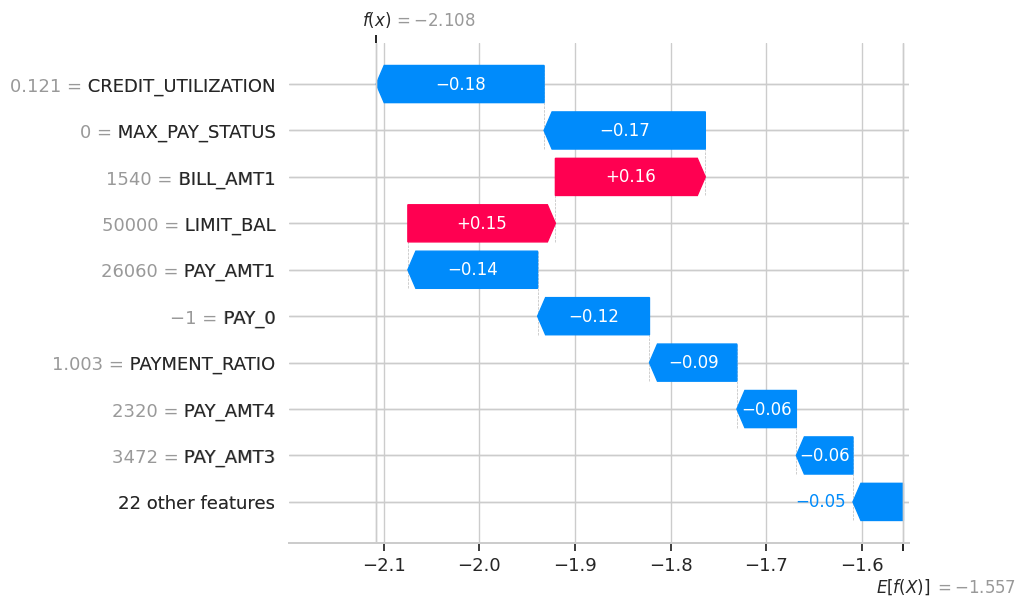

In [ ]:
sample = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample],
        feature_names=X_test.columns
    )
)

In [ ]:
import joblib

joblib.dump(
    shap_values,
    os.path.join(
        RESULT_PATH,
        "SHAP_Values.pkl"
    )
)

['/content/drive/MyDrive/Credit_Card_Default_Prediction/Results/SHAP_Values.pkl']

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 6.2 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

In [ ]:
def objective_catboost(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 200, 600),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 0.1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 5),

        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_state": 42,
        "verbose": 0
    }

    model = CatBoostClassifier(**params)

    model.fit(X_train, y_train)

    preds = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, preds)

    return auc

In [ ]:
study_cat = optuna.create_study(direction="maximize")

study_cat.optimize(
    objective_catboost,
    n_trials=50
)

[I 2026-07-12 21:39:53,714] A new study created in memory with name: no-name-4485eb00-6fbc-4146-8b93-b7fe529ae005
[I 2026-07-12 21:40:05,393] Trial 0 finished with value: 0.7722614367743894 and parameters: {'iterations': 309, 'depth': 7, 'learning_rate': 0.12027297535508341, 'l2_leaf_reg': 6.4709702116496866, 'random_strength': 0.11445565735858775, 'bagging_temperature': 1.0420344227624585}. Best is trial 0 with value: 0.7722614367743894.
[I 2026-07-12 21:40:20,845] Trial 1 finished with value: 0.7656350007926049 and parameters: {'iterations': 576, 'depth': 5, 'learning_rate': 0.17555273614682246, 'l2_leaf_reg': 6.833415764254375, 'random_strength': 3.5231868077922104, 'bagging_temperature': 3.5859995547328154}. Best is trial 0 with value: 0.7722614367743894.
[I 2026-07-12 21:40:27,496] Trial 2 finished with value: 0.7750520031136557 and parameters: {'iterations': 267, 'depth': 4, 'learning_rate': 0.0251842870864392, 'l2_leaf_reg': 5.859788440490495, 'random_strength': 7.24963794486087

In [ ]:
print("Best AUC:", study_cat.best_value)

print("\nBest Parameters")

print(study_cat.best_params)

Best AUC: 0.7835973818071105

Best Parameters
{'iterations': 600, 'depth': 5, 'learning_rate': 0.026663001290521203, 'l2_leaf_reg': 6.570456605595988, 'random_strength': 0.1554903930688259, 'bagging_temperature': 0.6724769499240364}


In [ ]:
best_cat = CatBoostClassifier(
    **study_cat.best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=42,
    verbose=0
)

best_cat.fit(X_train, y_train)

CatBoostClassifier(bagging_temperature=0.6724769499240364, depth=5, eval_metric='AUC', iterations=600, l2_leaf_reg=6.570456605595988, learning_rate=0.026663001290521203, loss_function='Logloss', random_state=42, random_strength=0.1554903930688259, verbose=0)

CatBoost + Optuna
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: CatBoost + Optuna_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

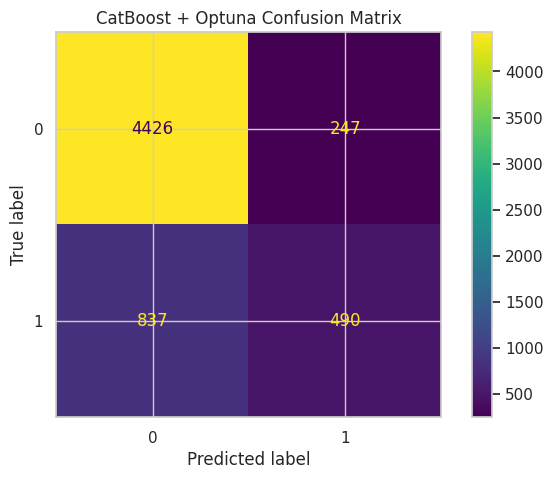

✅ Figure saved: CatBoost + Optuna_ROC.png


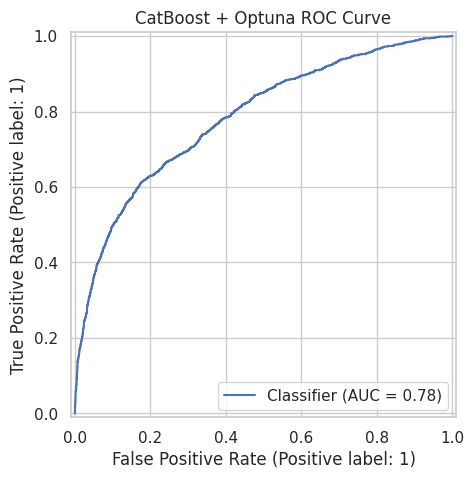

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,CatBoost + Optuna,0.819333,0.664858,0.369254,0.474806,0.783597,13.249934,0.03835


In [ ]:
best_cat_result = evaluate_model(
    best_cat,
    "CatBoost + Optuna",
    X_train,
    X_test,
    y_train,
    y_test
)

display(pd.DataFrame([best_cat_result]))

In [ ]:
save_model(best_cat, "CatBoost_Optuna")

save_results(
    pd.DataFrame([best_cat_result]),
    "CatBoost_Optuna_Results"
)

import joblib

joblib.dump(
    study_cat,
    os.path.join(
        RESULT_PATH,
        "CatBoost_Optuna_Study.pkl"
    )
)

✅ Model saved: CatBoost_Optuna.pkl
✅ Results saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Results/CatBoost_Optuna_Results.csv


['/content/drive/MyDrive/Credit_Card_Default_Prediction/Results/CatBoost_Optuna_Study.pkl']

In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

def objective_lgbm(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 700),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "num_leaves": trial.suggest_int("num_leaves", 15, 80),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "random_state":42,
        "verbosity":-1
    }

    model = LGBMClassifier(**params)

    model.fit(X_train, y_train)

    pred = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, pred)

    return auc

In [ ]:
study_lgbm = optuna.create_study(direction="maximize")

study_lgbm.optimize(
    objective_lgbm,
    n_trials=50
)

[I 2026-07-12 21:52:02,970] A new study created in memory with name: no-name-ff77c646-ca7a-421f-ad54-3d35212e0a4e
[I 2026-07-12 21:52:08,023] Trial 0 finished with value: 0.7776407494769855 and parameters: {'n_estimators': 438, 'learning_rate': 0.02467492362761888, 'max_depth': 10, 'num_leaves': 51, 'min_child_samples': 12, 'subsample': 0.8307600958325345, 'colsample_bytree': 0.7725943847706016}. Best is trial 0 with value: 0.7776407494769855.
[I 2026-07-12 21:52:11,998] Trial 1 finished with value: 0.7787160475988745 and parameters: {'n_estimators': 323, 'learning_rate': 0.024809994309592517, 'max_depth': 7, 'num_leaves': 57, 'min_child_samples': 28, 'subsample': 0.6354052023713935, 'colsample_bytree': 0.8458379265674969}. Best is trial 1 with value: 0.7787160475988745.
[I 2026-07-12 21:52:13,856] Trial 2 finished with value: 0.7679012222243544 and parameters: {'n_estimators': 277, 'learning_rate': 0.1773830016360555, 'max_depth': 5, 'num_leaves': 73, 'min_child_samples': 45, 'subsamp

In [ ]:
print("Best ROC AUC:", study_lgbm.best_value)
print("\nBest Parameters:\n")
print(study_lgbm.best_params)

Best ROC AUC: 0.7831247215198794

Best Parameters:

{'n_estimators': 428, 'learning_rate': 0.01165784955623469, 'max_depth': 4, 'num_leaves': 72, 'min_child_samples': 48, 'subsample': 0.6752606258728292, 'colsample_bytree': 0.8968737298085363}


In [ ]:
best_lgbm = LGBMClassifier(
    **study_lgbm.best_params,
    random_state=42,
    verbosity=-1
)

best_lgbm.fit(X_train, y_train)

LGBMClassifier(colsample_bytree=0.8968737298085363,
               learning_rate=0.01165784955623469, max_depth=4,
               min_child_samples=48, n_estimators=428, num_leaves=72,
               random_state=42, subsample=0.6752606258728292, verbosity=-1)

LightGBM + Optuna
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: LightGBM + Optuna_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

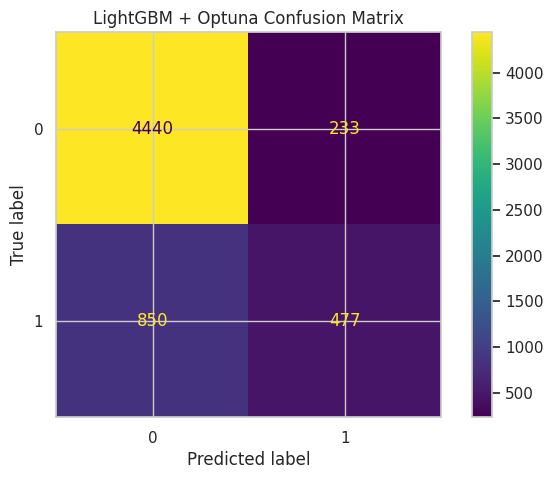

✅ Figure saved: LightGBM + Optuna_ROC.png


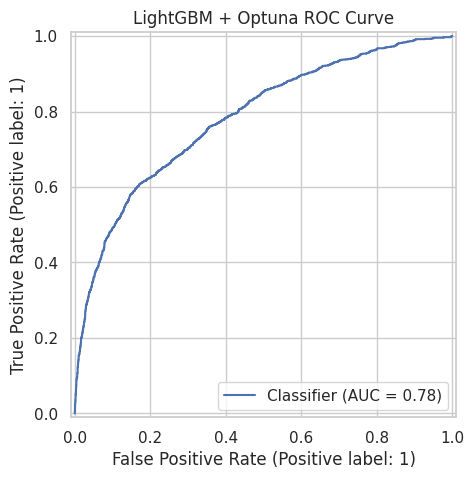

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,LightGBM + Optuna,0.8195,0.671831,0.359457,0.468336,0.783125,3.305705,0.349797


In [ ]:
lgbm_optuna_result = evaluate_model(
    best_lgbm,
    "LightGBM + Optuna",
    X_train,
    X_test,
    y_train,
    y_test
)

display(pd.DataFrame([lgbm_optuna_result]))

In [ ]:
save_model(best_lgbm, "LightGBM_Optuna")

save_results(
    pd.DataFrame([lgbm_optuna_result]),
    "LightGBM_Optuna_Results"
)

import joblib

joblib.dump(
    study_lgbm,
    os.path.join(
        RESULT_PATH,
        "LightGBM_Optuna_Study.pkl"
    )
)

print("✅ LightGBM Optuna results saved successfully.")

✅ Model saved: LightGBM_Optuna.pkl
✅ Results saved at:
/content/drive/MyDrive/Credit_Card_Default_Prediction/Results/LightGBM_Optuna_Results.csv
✅ LightGBM Optuna results saved successfully.


In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        "objective": "binary:logistic",
        "eval_metric": "auc",
        "random_state": 42,
        "verbosity": 0
    }

    model = XGBClassifier(**params)

    model.fit(X_train, y_train)

    pred = model.predict_proba(X_test)[:,1]

    return roc_auc_score(y_test, pred)

In [ ]:
study_xgb = optuna.create_study(direction="maximize")

study_xgb.optimize(
    objective_xgb,
    n_trials=50
)

[I 2026-07-12 21:58:06,487] A new study created in memory with name: no-name-6336d4c6-0ddf-46b7-835a-761a782880fc
[I 2026-07-12 21:58:33,654] Trial 0 finished with value: 0.7703803907421799 and parameters: {'n_estimators': 480, 'max_depth': 9, 'learning_rate': 0.06862691891989631, 'subsample': 0.7321980307133699, 'colsample_bytree': 0.7575492752506534, 'gamma': 2.6433211380051307, 'min_child_weight': 3}. Best is trial 0 with value: 0.7703803907421799.
[I 2026-07-12 21:58:37,462] Trial 1 finished with value: 0.7810558047150243 and parameters: {'n_estimators': 329, 'max_depth': 3, 'learning_rate': 0.017379757547505856, 'subsample': 0.8793834616004452, 'colsample_bytree': 0.7339446791389385, 'gamma': 3.311575384755059, 'min_child_weight': 7}. Best is trial 1 with value: 0.7810558047150243.
[I 2026-07-12 21:58:49,166] Trial 2 finished with value: 0.7523057710514844 and parameters: {'n_estimators': 291, 'max_depth': 8, 'learning_rate': 0.17308419281218235, 'subsample': 0.8945634593486459, '

In [ ]:
print("Best ROC AUC:", study_xgb.best_value)
print("\nBest Parameters:")
print(study_xgb.best_params)

Best ROC AUC: 0.7831401220853623

Best Parameters:
{'n_estimators': 506, 'max_depth': 4, 'learning_rate': 0.04022886634494759, 'subsample': 0.8477158256823016, 'colsample_bytree': 0.9240067973281935, 'gamma': 3.641178229808509, 'min_child_weight': 2}


In [ ]:
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9240067973281935, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=3.641178229808509, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.04022886634494759,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=506, n_jobs=None,
              num_parallel_tree=None, ...)

XGBoost + Optuna
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: XGBoost + Optuna_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

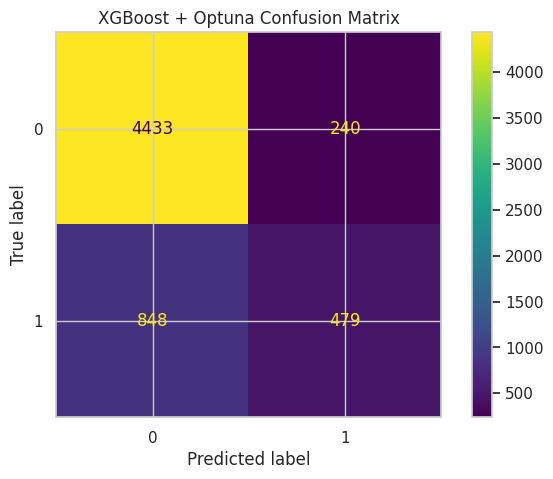

✅ Figure saved: XGBoost + Optuna_ROC.png


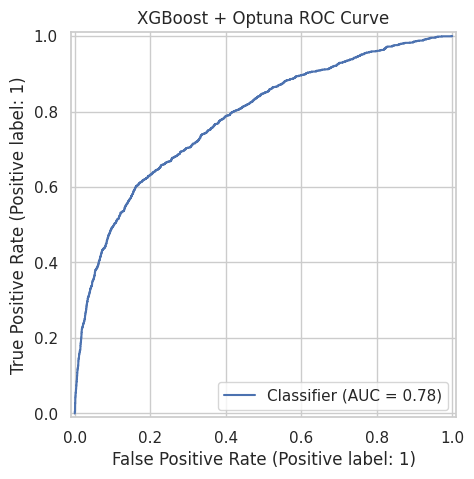

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,XGBoost + Optuna,0.818667,0.666203,0.360965,0.468231,0.78314,17.508557,0.142672


In [ ]:
xgb_optuna_result = evaluate_model(
    best_xgb,
    "XGBoost + Optuna",
    X_train,
    X_test,
    y_train,
    y_test
)

display(pd.DataFrame([xgb_optuna_result]))

In [ ]:
original_features = [
    "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

X_original = df[original_features]
y = df["default.payment.next.month"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train_org, X_test_org, y_train_org, y_test_org = train_test_split(
    X_original,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
cat_original = CatBoostClassifier(
    iterations=600,
    depth=5,
    learning_rate=0.026663001290521203,
    l2_leaf_reg=6.570456605595988,
    random_strength=0.1554903930688259,
    bagging_temperature=0.6724769499240364,
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=42,
    verbose=0
)

cat_original.fit(X_train_org, y_train_org)

CatBoostClassifier(bagging_temperature=0.6724769499240364, depth=5, eval_metric='AUC', iterations=600, l2_leaf_reg=6.570456605595988, learning_rate=0.026663001290521203, loss_function='Logloss', random_state=42, random_strength=0.1554903930688259, verbose=0)

Original Features
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000

✅ Figure saved: Original Features_Confusion_Matrix.png


<Figure size 500x500 with 0 Axes>

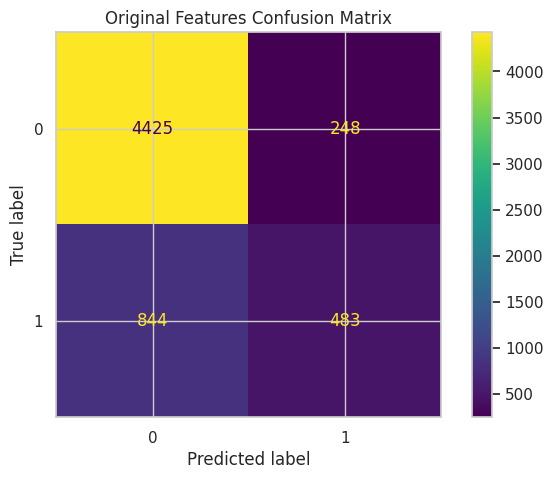

✅ Figure saved: Original Features_ROC.png


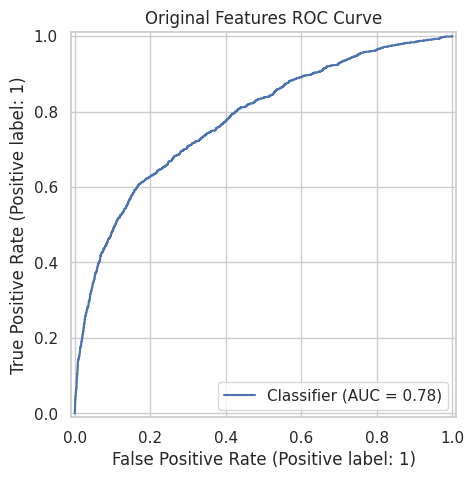

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,Original Features,0.818,0.660739,0.363979,0.469388,0.779958,15.894533,0.015463


In [ ]:
ablation_original = evaluate_model(
    cat_original,
    "Original Features",
    X_train_org,
    X_test_org,
    y_train_org,
    y_test_org
)

display(pd.DataFrame([ablation_original]))

## Phase 11: Stratified 5-Fold Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

In [ ]:
print(X_original.shape)
print(X_engineered.shape)
print(y.shape)

(30000, 23)


NameError: name 'X_engineered' is not defined

In [ ]:
# Show all dataframe variables currently available
for name, value in globals().items():
    if isinstance(value, pd.DataFrame):
        print(name, value.shape)

RuntimeError: dictionary changed size during iteration

In [ ]:
for name, value in list(globals().items()):
    if isinstance(value, pd.DataFrame):
        print(name, value.shape)

df (30000, 36)
corr (8, 8)
summary_stats (25, 8)
cat_summary (7, 3)
pay_summary (11, 6)
outliers (2958, 25)
outlier_df (14, 3)
class_dist (2, 2)
engineered_summary (8, 8)
X (30000, 31)
X_train (24000, 31)
X_test (6000, 31)
train_df (24000, 32)
test_df (6000, 32)
X_train_scaled (24000, 31)
X_test_scaled (6000, 31)
comparison (3, 6)
results (3, 8)
xgb_df (1, 8)
lgbm_df (1, 8)
cat_df (1, 8)
comparison_table (6, 8)
ablation_table (2, 4)
importance (31, 2)
feature_importance (31, 2)
top20 (20, 2)
cv_results (6, 3)
feature_table (36, 1)
X_original (30000, 23)
X_train_org (24000, 23)
X_test_org (6000, 23)


In [ ]:
for name, value in list(globals().items()):
    if isinstance(value, (pd.Series, np.ndarray)):
        print(name, value.shape)

default_percent (2,)
temp (10,)
y (30000,)
y_train (24000,)
y_test (6000,)
lr_predictions (6000,)
dt_predictions (6000,)
rf_predictions (6000,)
shap_values (6000, 31)
scores (5,)
y_train_org (24000,)
y_test_org (6000,)


In [ ]:
X_original = X_original
X_engineered = X
y = y

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

import numpy as np
from catboost import CatBoostClassifier


def cross_validate_catboost(X_data, y_data):

    auc_scores = []
    acc_scores = []
    f1_scores = []
    precision_scores = []
    recall_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_data, y_data)):

        print(f"Fold {fold+1}")

        X_train_cv = X_data.iloc[train_idx]
        X_test_cv = X_data.iloc[test_idx]

        y_train_cv = y_data.iloc[train_idx]
        y_test_cv = y_data.iloc[test_idx]


        model = CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=42,
            verbose=0
        )


        model.fit(
            X_train_cv,
            y_train_cv
        )


        y_prob = model.predict_proba(X_test_cv)[:,1]
        y_pred = model.predict(X_test_cv)


        auc_scores.append(
            roc_auc_score(y_test_cv, y_prob)
        )

        acc_scores.append(
            accuracy_score(y_test_cv, y_pred)
        )

        f1_scores.append(
            f1_score(y_test_cv, y_pred)
        )

        precision_scores.append(
            precision_score(y_test_cv, y_pred)
        )

        recall_scores.append(
            recall_score(y_test_cv, y_pred)
        )


    return {
        "Mean ROC-AUC": np.mean(auc_scores),
        "Std ROC-AUC": np.std(auc_scores),
        "Mean Accuracy": np.mean(acc_scores),
        "Mean F1": np.mean(f1_scores),
        "Mean Precision": np.mean(precision_scores),
        "Mean Recall": np.mean(recall_scores),
        "Fold ROC-AUC": auc_scores
    }

In [ ]:
results_original_cv = cross_validate_catboost(
    X_original,
    y
)

results_original_cv

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


{'Mean ROC-AUC': np.float64(0.7831449040684422),
 'Std ROC-AUC': np.float64(0.005312066554224123),
 'Mean Accuracy': np.float64(0.8208),
 'Mean F1': np.float64(0.4785669886166448),
 'Mean Precision': np.float64(0.6716125864793097),
 'Mean Recall': np.float64(0.3717606295566592),
 'Fold ROC-AUC': [np.float64(0.792595789837432),
  np.float64(0.7781977500338249),
  np.float64(0.7824083936468395),
  np.float64(0.7843964373251008),
  np.float64(0.7781261494990139)]}

In [ ]:
results_engineered_cv = cross_validate_catboost(
    X,
    y
)

results_engineered_cv

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


{'Mean ROC-AUC': np.float64(0.7858641856380475),
 'Std ROC-AUC': np.float64(0.005157955426726427),
 'Mean Accuracy': np.float64(0.8193000000000001),
 'Mean F1': np.float64(0.474837072582967),
 'Mean Precision': np.float64(0.6648229078621906),
 'Mean Recall': np.float64(0.3693501965662197),
 'Fold ROC-AUC': [np.float64(0.7949005998308301),
  np.float64(0.7798768148276322),
  np.float64(0.7845183517492381),
  np.float64(0.7874880000567643),
  np.float64(0.7825371617257729)]}

In [ ]:
cv_comparison = pd.DataFrame({
    "Feature Set":[
        "Original Features",
        "Original + Engineered Features"
    ],

    "Mean ROC-AUC":[
        results_original_cv["Mean ROC-AUC"],
        results_engineered_cv["Mean ROC-AUC"]
    ],

    "Std ROC-AUC":[
        results_original_cv["Std ROC-AUC"],
        results_engineered_cv["Std ROC-AUC"]
    ],

    "Accuracy":[
        results_original_cv["Mean Accuracy"],
        results_engineered_cv["Mean Accuracy"]
    ],

    "F1 Score":[
        results_original_cv["Mean F1"],
        results_engineered_cv["Mean F1"]
    ]
})

cv_comparison

,Feature Set,Mean ROC-AUC,Std ROC-AUC,Accuracy,F1 Score
0,Original Features,0.783145,0.005312,0.8208,0.478567
1,Original + Engineered Features,0.785864,0.005158,0.8193,0.474837


In [ ]:
from scipy.stats import wilcoxon


original_scores = results_original_cv["Fold ROC-AUC"]
engineered_scores = results_engineered_cv["Fold ROC-AUC"]


stat, p_value = wilcoxon(
    engineered_scores,
    original_scores,
    alternative="greater"
)


print("Wilcoxon Statistic:", stat)
print("p-value:", p_value)

Wilcoxon Statistic: 15.0
p-value: 0.03125


In [ ]:
improvements = np.array(engineered_scores) - np.array(original_scores)

print("Fold Improvements:")
print(improvements)

print("Mean Improvement:")
print(improvements.mean())

Fold Improvements:
[0.00230481 0.00167906 0.00210996 0.00309156 0.00441101]
Mean Improvement:
0.002719281569605325


In [ ]:
final_catboost = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

final_catboost.fit(
    X_train,
    y_train
)

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=0)

In [ ]:
final_catboost.save_model(
    "Models/final_catboost_engineered.cbm"
)

CatBoostError: (Error 2: No such file or directory) util/system/file.cpp:936: can't open "Models/final_catboost_engineered.cbm" with mode WrOnly|CreateAlways|Seq (0x00000034)

In [ ]:
import os

os.makedirs("Models", exist_ok=True)

In [ ]:
os.listdir("Models")

[]

In [ ]:
final_catboost.save_model(
    "Models/final_catboost_engineered.cbm"
)

In [ ]:
os.listdir("Models")

['final_catboost_engineered.cbm']

In [ ]:
from catboost import CatBoostClassifier

catboost_original = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

catboost_original.fit(
    X_train_org,
    y_train_org
)

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=0)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Original features
y_prob_original = catboost_original.predict_proba(
    X_test_org
)[:,1]


# Engineered features
y_prob_engineered = final_catboost.predict_proba(
    X_test
)[:,1]


auc_original = roc_auc_score(
    y_test_org,
    y_prob_original
)


auc_engineered = roc_auc_score(
    y_test,
    y_prob_engineered
)


print("Original Features ROC-AUC:", auc_original)
print("Engineered Features ROC-AUC:", auc_engineered)

Original Features ROC-AUC: 0.7802618289647063
Engineered Features ROC-AUC: 0.7813779264904401


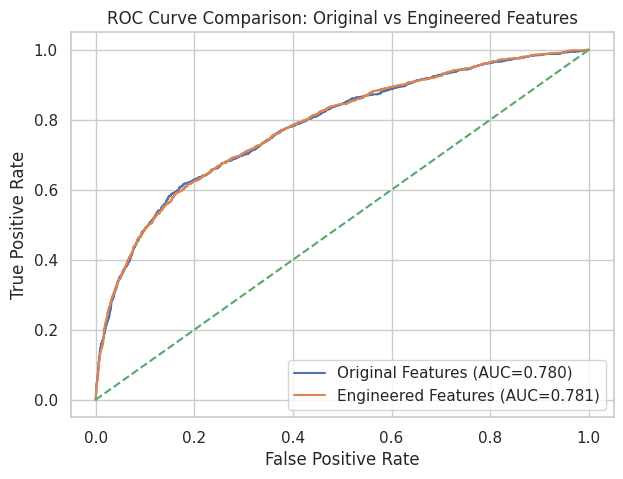

In [ ]:
import matplotlib.pyplot as plt


fpr_original, tpr_original, _ = roc_curve(
    y_test_org,
    y_prob_original
)

fpr_engineered, tpr_engineered, _ = roc_curve(
    y_test,
    y_prob_engineered
)


plt.figure(figsize=(7,5))


plt.plot(
    fpr_original,
    tpr_original,
    label=f"Original Features (AUC={auc_original:.3f})"
)


plt.plot(
    fpr_engineered,
    tpr_engineered,
    label=f"Engineered Features (AUC={auc_engineered:.3f})"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison: Original vs Engineered Features"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
import os
os.makedirs("Figures", exist_ok=True)

In [ ]:
plt.savefig(
    "Figures/ROC_Curve_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 800x500 with 0 Axes>

In [ ]:
print("Original Features ROC-AUC:", auc_original)
print("Engineered Features ROC-AUC:", auc_engineered)

Original Features ROC-AUC: 0.7802618289647063
Engineered Features ROC-AUC: 0.7813779264904401


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


precision_original, recall_original, _ = precision_recall_curve(
    y_test_org,
    y_prob_original
)

precision_engineered, recall_engineered, _ = precision_recall_curve(
    y_test,
    y_prob_engineered
)


ap_original = average_precision_score(
    y_test_org,
    y_prob_original
)

ap_engineered = average_precision_score(
    y_test,
    y_prob_engineered
)


print("Original Average Precision:", ap_original)
print("Engineered Average Precision:", ap_engineered)

Original Average Precision: 0.5566396986766204
Engineered Average Precision: 0.557562642355582


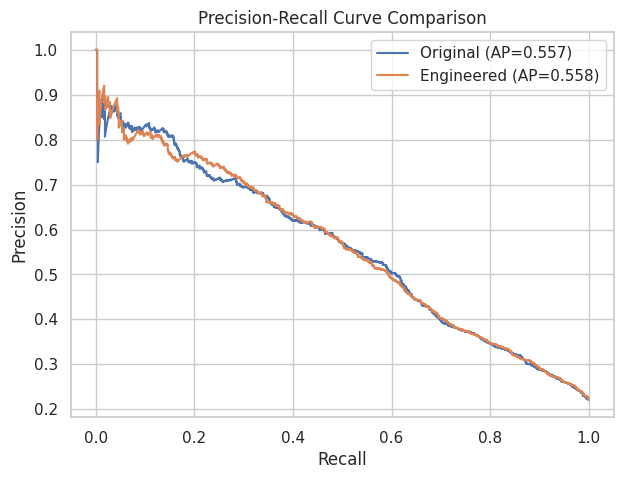

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    recall_original,
    precision_original,
    label=f"Original (AP={ap_original:.3f})"
)

plt.plot(
    recall_engineered,
    precision_engineered,
    label=f"Engineered (AP={ap_engineered:.3f})"
)


plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import average_precision_score

# Average Precision for Original Features
ap_original = average_precision_score(
    y_test_org,
    y_prob_original
)

# Average Precision for Engineered Features
ap_engineered = average_precision_score(
    y_test,
    y_prob_engineered
)

print("Original Features Average Precision:", ap_original)
print("Engineered Features Average Precision:", ap_engineered)

print("Improvement:", ap_engineered - ap_original)

Original Features Average Precision: 0.5566396986766204
Engineered Features Average Precision: 0.557562642355582
Improvement: 0.0009229436789615075


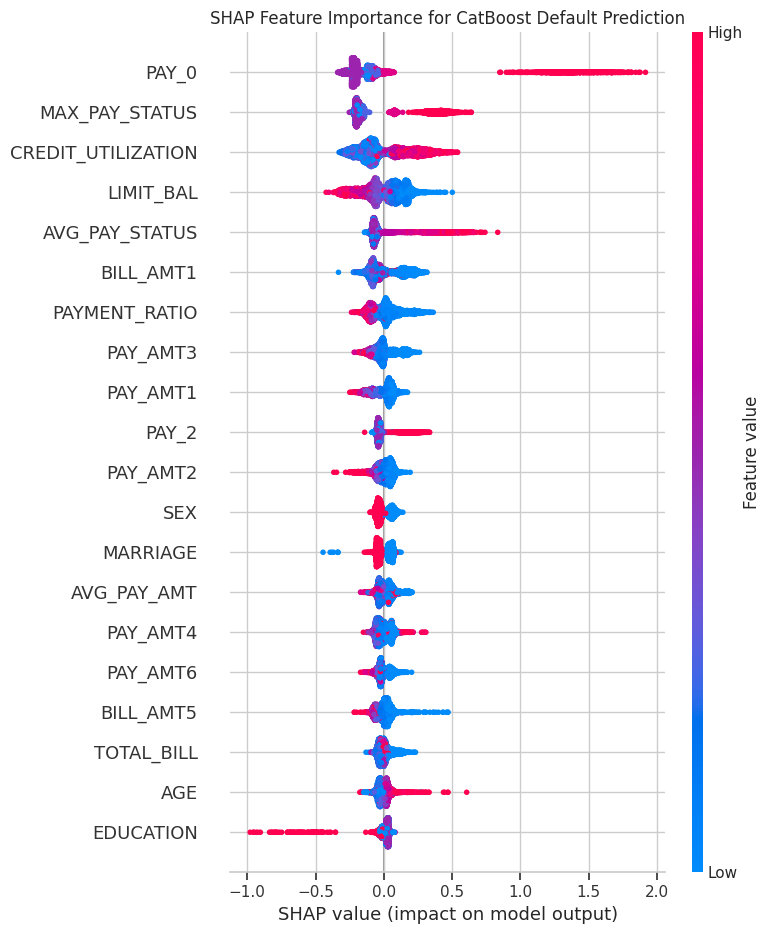

In [ ]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explanation plot
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Feature Importance for CatBoost Default Prediction"
)

plt.tight_layout()

plt.savefig(
    "Figures/SHAP_Summary_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Calculate mean absolute SHAP importance
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP_Impact": np.abs(shap_values).mean(axis=0)
})

# Sort by importance
shap_importance = shap_importance.sort_values(
    by="Mean_SHAP_Impact",
    ascending=False
)

# Display top 10 features
top10_shap_features = shap_importance.head(10)

top10_shap_features

In [ ]:
top10_shap_features.to_csv(
    "Tables/Top10_SHAP_Features.csv",
    index=False
)

In [ ]:
import os

os.makedirs("Tables", exist_ok=True)

In [ ]:
top10_shap_features.to_csv(
    "Tables/Top10_SHAP_Features.csv",
    index=False
)

In [ ]:
os.listdir("Tables")

['Top10_SHAP_Features.csv']

In [ ]:
top10_shap_features.to_csv(
    "Tables/Top10_SHAP_Features.csv",
    index=False
)

In [ ]:
import pandas as pd
import numpy as np

# Calculate mean absolute SHAP importance
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP_Impact": np.abs(shap_values).mean(axis=0)
})

# Sort features by importance
shap_importance = shap_importance.sort_values(
    by="Mean_SHAP_Impact",
    ascending=False
)

# Select top 10 features
top10_shap_features = shap_importance.head(10)

# Display
top10_shap_features

,Feature,Mean_SHAP_Impact
5,PAY_0,0.289937
26,MAX_PAY_STATUS,0.238790
29,CREDIT_UTILIZATION,0.155517
0,LIMIT_BAL,0.120826
25,AVG_PAY_STATUS,0.113757
11,BILL_AMT1,0.099831
30,PAYMENT_RATIO,0.076911
19,PAY_AMT3,0.063309
17,PAY_AMT1,0.060052
6,PAY_2,0.058950


In [ ]:
import os

os.makedirs("Tables", exist_ok=True)

In [ ]:
top10_shap_features.to_csv(
    "Tables/Top10_SHAP_Features.csv",
    index=False
)

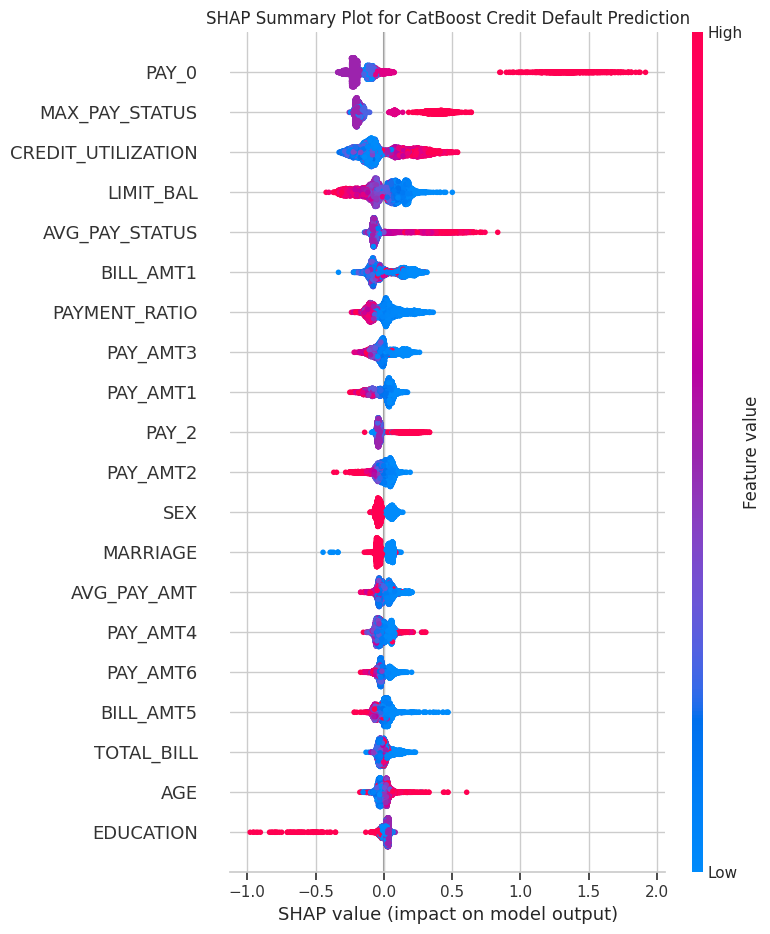

In [ ]:
import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot for CatBoost Credit Default Prediction"
)

plt.tight_layout()

plt.savefig(
    "Figures/SHAP_Summary_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )
}

In [ ]:
results = []

for name, model in models.items():

    print("Training:", name)

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability prediction
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: XGBoost
Training: LightGBM
Training: CatBoost


In [ ]:
table4 = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)


# Round values
table4 = table4.round(4)


table4

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7788,0.0000,0.0000,0.0000,0.6329
1,Decision Tree,0.7312,0.3983,0.4220,0.4098,0.6217
2,Random Forest,0.8118,0.6296,0.3625,0.4601,0.7573
3,XGBoost,0.8198,0.6694,0.3662,0.4735,0.7795
4,LightGBM,0.8188,0.6667,0.3617,0.4690,0.7746
5,CatBoost,0.8168,0.6570,0.3595,0.4647,0.7814


In [ ]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# Define models
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )
}


# Store results
engineered_results = []


# Train and evaluate
for name, model in models.items():

    print("Training:", name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]


    engineered_results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])


# Create Table 4
table4_engineered = pd.DataFrame(
    engineered_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)


# Round for paper
table4_engineered = table4_engineered.round(4)


table4_engineered

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: XGBoost
Training: LightGBM
Training: CatBoost


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7788,0.0000,0.0000,0.0000,0.6329
1,Decision Tree,0.7312,0.3983,0.4220,0.4098,0.6217
2,Random Forest,0.8118,0.6296,0.3625,0.4601,0.7573
3,XGBoost,0.8198,0.6694,0.3662,0.4735,0.7795
4,LightGBM,0.8188,0.6667,0.3617,0.4690,0.7746
5,CatBoost,0.8168,0.6570,0.3595,0.4647,0.7814
